# GROWL onboarding — Notebook 2: A *population* of gravitational-wave sources

**Welcome back to the GROWL (GRavitatiOnal Wave paLentology) task force!** 🦖🦖 🦕🦕

In [Notebook 1](introduction_to_population_synthesis.ipynb) you followed **one** binary from two
ordinary massive stars all the way to a binary black hole. That is the right way to build
intuition — but one binary tells you nothing about what
[LIGO](https://en.wikipedia.org/wiki/LIGO)/Virgo/KAGRA actually observe. For that you need a
**population**: millions of binaries, evolved with the same physics, collected into one table.

This notebook is about **reading and plotting such a population** — a published, peer-reviewed
dataset of ~2.5 million simulated double compact objects from
**van Son et al. (2022, 2023)**.

**No prior astrophysics is assumed.** Every technical term is defined the first time it appears,
with a link to a readable (usually Wikipedia) explanation, and there is a
[glossary](#glossary) at the bottom.

### What you will do

| Part | What you do | Time |
|------|-------------|------|
| **0** | Learn what a "population of gravitational-wave sources" *is*, and what these numbers mean | ~10 min reading |
| **1** | Download and open a real published dataset; find out what is stored in it | ~15 min |
| **2** | Select the binary black holes that actually merge | ~10 min |
| **3** | Plot the **1D black hole mass distribution** and understand every feature in it, including the **pair-instability mass gap** | ~25 min |
| **4** | Plot the **2D distribution** $m_1$ vs $m_2$ | ~15 min |
| **5** | Plot $\log_{10}(\text{separation})$ vs **mass ratio**, find the **two islands**, and work out what makes them | ~25 min |
| **6** | Bonus: see how **metallicity** controls the maximum black hole mass | ~10 min |
| **7** | Exercises | 🎓 |

### What you need

- Python with `numpy`, `matplotlib`, `pandas` and `h5py`.
- The van Son et al. data file (**3 GB download, 5.6 GB unpacked**) — download instructions in
  [Part 1](#part1). Start the download *now*, it takes a while.
- ~2 GB of free RAM. (We only read the columns we need — the file itself never gets loaded whole.)

### Learning objectives

By the end of this notebook you should be able to:

1. Explain what the rows and columns of a population synthesis output file represent, and why
   there are several *groups* with different numbers of rows.
2. Explain why the simulated binaries carry **statistical weights**, and why ignoring them gives
   you the wrong answer.
3. Select **binary black holes that merge within the age of the Universe** from a mixed catalogue
   of compact objects.
4. Make and *read* a 1D mass distribution, and explain its sharp features: the lower edge, the
   peak, and the **pair-instability supernova (PISN) mass gap**.
5. Make 2D distributions and recognise that a population splits into **distinct islands** that
   correspond to **different formation channels** (common envelope vs. stable mass transfer).
6. State clearly what this "raw" simulated population is **not**: it is not yet a prediction of
   what LIGO will see. (That last step, *cosmic integration*, is the next notebook.)

<a id="part0"></a>
# Part 0 — What is a "population of gravitational-wave sources"?

## 0.1 A one-paragraph recap of Notebook 1

A **rapid population synthesis code** such as [COMPAS](https://compas.science/) takes a pair of
newborn stars — described by two masses, an orbital separation, an eccentricity and a
[metallicity](https://en.wikipedia.org/wiki/Metallicity) — and evolves them forward in time in a
few milliseconds, using fitted formulae and prescriptions instead of solving the full stellar
structure equations. Along the way the binary may experience
[stellar winds](https://en.wikipedia.org/wiki/Stellar_wind),
[mass transfer](https://en.wikipedia.org/wiki/Roche_lobe),
[common envelope evolution](https://en.wikipedia.org/wiki/Common_envelope) and
[supernovae](https://en.wikipedia.org/wiki/Supernova) with natal kicks. A tiny fraction of
binaries survive all of that and end up as **two compact objects in a tight orbit**.

Because each binary is cheap, we can run **millions** of them. That collection is a *population*.

## 0.2 What actually gets detected

Two compact objects orbiting each other radiate
[**gravitational waves**](https://en.wikipedia.org/wiki/Gravitational_wave) — ripples in
spacetime, predicted by Einstein in 1916 and first directly detected in 2015
([GW150914](https://en.wikipedia.org/wiki/GW150914)). The waves carry away orbital energy, so the
orbit shrinks; eventually the two objects spiral together and **merge**, producing a burst of
gravitational waves loud enough for LIGO to hear.

Two things follow that are essential for this notebook:

1. **Only *merging* systems are detectable.** A pair of black holes 1000 R$_\odot$ apart is
   perfectly real but will take far longer than the age of the Universe to merge, so it is
   invisible. We will therefore always apply the cut *"does this system merge within a
   [Hubble time](https://en.wikipedia.org/wiki/Hubble%27s_law#Hubble_time)"* (~13.7 billion years).
2. **The quantity that controls the merger time is the orbital separation, raised to the fourth
   power.** [Peters (1964)](https://journals.aps.org/pr/abstract/10.1103/PhysRev.136.B1224) showed
   that for a circular orbit
   $$t_{\rm merge} = \frac{5}{256}\,\frac{c^5\,a^4}{G^3\,m_1\,m_2\,(m_1+m_2)}.$$
   Halve the separation and the merger time drops by a factor of 16. This is why the
   orbit-shrinking processes from Notebook 1 matter so enormously.

📺 If you have never seen it: the [LIGO detections catalogue](https://gwosc.org/eventapi/html/GWTC/)
lists every gravitational-wave event observed so far, with the measured masses. It is worth two
minutes of browsing before you continue — those are the *real* numbers our simulation is trying
to reproduce.

## 0.3 What "raw" data means here — and what it is *not*

This notebook plots the **raw simulation output**: a list of the compact-object binaries the code
made, exactly as it made them. That is *not yet* a prediction of what LIGO will detect, for two
reasons:

- **The simulation's mix of metallicities is not the Universe's mix.** The authors deliberately
  spread their binaries uniformly in $\log Z$ so that every metallicity is well sampled. The real
  Universe made most of its stars at particular metallicities, at particular cosmic times.
- **The Universe is not static.** To predict a detection rate you must fold in the
  [cosmic star formation history](https://en.wikipedia.org/wiki/Star_formation) — how many stars
  formed, when, and at what metallicity — plus the time each binary takes to merge, plus the
  detector's sensitivity.

That folding-in step is called **cosmic integration**, and it is deliberately **not** in this
notebook — it gets its own. Here we want you to become fluent with the raw ingredients first.

> ⚠️ **Carry this caveat with you.** Every plot below answers *"what did the code make?"*, not
> *"what will LIGO see?"*. Those two questions have genuinely different answers, and confusing
> them is the single most common mistake newcomers make with this kind of data.

## 0.4 Vocabulary, defined once

| Term | Meaning |
|---|---|
| **Compact object** | The dense remnant left when a star dies: a [white dwarf](https://en.wikipedia.org/wiki/White_dwarf), a [neutron star](https://en.wikipedia.org/wiki/Neutron_star) (NS), or a [black hole](https://en.wikipedia.org/wiki/Black_hole) (BH). |
| **DCO** | *Double compact object* — any pair of them in a bound orbit. |
| **BBH** | [*Binary black hole*](https://en.wikipedia.org/wiki/Binary_black_hole) — a DCO where both objects are black holes. The most common LIGO detection. |
| **BHNS / BNS** | Black hole + neutron star / two neutron stars. |
| $m_1, m_2$ | By the convention **of this notebook**, $m_1$ is the **more massive** black hole and $m_2$ the less massive one, *at the moment the binary black hole forms*. So $m_1 \ge m_2$ always. |
| **Mass ratio** $q$ | $q \equiv m_2/m_1$, so $0 < q \le 1$. $q=1$ means twins. |
| **Chirp mass** $\mathcal{M}_c$ | $\mathcal{M}_c = (m_1 m_2)^{3/5}/(m_1+m_2)^{1/5}$. The mass combination that gravitational-wave detectors measure **most precisely**, because it sets how fast the signal sweeps up in frequency. See [chirp mass](https://en.wikipedia.org/wiki/Chirp_mass). |
| **Separation** $a$ | The [semi-major axis](https://en.wikipedia.org/wiki/Semi-major_and_semi-minor_axes) of the orbit — roughly, the average distance between the two objects. |
| **M$_\odot$** | One [solar mass](https://en.wikipedia.org/wiki/Solar_mass), ~2 × 10³⁰ kg. **R$_\odot$**: one solar radius, ~696,000 km. |
| **Metallicity** $Z$ | Mass fraction of elements heavier than helium. Solar ≈ 0.014. |
| **Delay time** | Time between the birth of the stars and the merger of the two compact objects. |

<a id="part1"></a>
# Part 1 — The dataset

## 1.1 Where it comes from

We use the fiducial COMPAS simulation published by **Lieke van Son and collaborators**. It is the
same simulation behind two papers you should know about:

| | |
| 📄 **van Son et al. (2022)**, *The redshift evolution of the binary black hole merger rate: a weighty matter*, ApJ **931**, 17 | 👉 https://arxiv.org/abs/2110.01634 |
| 📄 **van Son et al. (2023)**, *The locations of features in the mass distribution of merging binary black holes are robust against uncertainties in the metallicity-dependent cosmic star formation history*, ApJ **948**, 105 | 👉 https://arxiv.org/abs/2209.03385 |
| 💾 **Data (Zenodo)**, DOI `10.5281/zenodo.7612755` | 👉 https://doi.org/10.5281/zenodo.7612755 |
| 💻 Analysis code by the authors | 👉 https://github.com/LiekeVanSon/SFRD_fit |
| 💻 The simulation code, COMPAS ([methods paper](https://arxiv.org/abs/2109.10352)) | 👉 https://compas.science/ |

The first of those papers is the one whose *physics* we will rediscover in Part 5. Skim its
abstract before you start — it is short, and it tells you what to look for.

## 1.2 Download instructions

1. Go to **https://doi.org/10.5281/zenodo.7612755**
2. Download **`COMPAS_Output_wWeights.tar.gz`** (3.0 GB).
3. Unpack it — e.g. `tar -xvzf COMPAS_Output_wWeights.tar.gz` — to get
   **`COMPAS_Output_wWeights.h5`** (5.6 GB).
4. Put it somewhere sensible and set `DATA_PATH` in the next cell to point at it.

> 🙏 **Please credit the authors** if you use this data for anything beyond this tutorial: cite
> both the Zenodo DOI and van Son et al. (2022, 2023). Reusing someone's simulation is a gift they
> gave you; citation is how you say thank you.

> 🗃️ **Do not commit the file to git.** It is 5.6 GB. Keep it outside the repository, or add it
> to your `.gitignore`.

The format is [**HDF5**](https://en.wikipedia.org/wiki/Hierarchical_Data_Format) — a binary
container for large scientific arrays, read in Python with
[`h5py`](https://docs.h5py.org/). The mental model you want is: *a file system inside a file*.
It contains **groups** (like folders) which contain **datasets** (like named columns), and reading
one column does **not** read the rest of the file off disk. That is exactly why we can work
comfortably with a 5.6 GB file on a laptop.

In [2]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm

# --- plotting style: keep grid/axes recessive so the data dominates -------------
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": ":",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

# Colour convention used throughout this notebook:
#   more massive BH = dark red, less massive BH = blue, everything together = black
#   common-envelope channel = orange, stable-mass-transfer channel = teal
C1, C2, CSYS = "#C1272D", "#0B5FA5", "#222222"
C_CE, C_SMT = "#E07B39", "#2A9D8F"


def weighted_median(x, w):
    '''Median of x where each entry carries a statistical weight w (see section 1.4).'''
    order = np.argsort(np.asarray(x))
    x_sorted = np.asarray(x)[order]
    cum_w = np.cumsum(np.asarray(w)[order])
    return x_sorted[np.searchsorted(cum_w, 0.5 * cum_w[-1])]


# >>> CHANGE THIS LINE to wherever you unpacked the file <<<
DATA_PATH = "data/vanSon2022_data/COMPAS_Output_wWeights.h5"

print("numpy", np.__version__, "| h5py", h5py.__version__, "| pandas", pd.__version__)

numpy 2.3.3 | h5py 3.15.1 | pandas 2.2.3


## 1.3 First look: what is inside the file?

**Always do this before touching a new dataset.** Never assume you know what the columns are —
open the file and look. Below we walk the whole hierarchy and print every group, every dataset,
its shape and its data type.

In [3]:
DATA_PATH = "data/COMPAS_Output_wWeights.h5"
with h5py.File(DATA_PATH, "r") as f:
    for group in f.keys():
        n_rows = f[group][list(f[group].keys())[0]].shape[0]
        print(f"\nGROUP  {group}   ({n_rows:,} rows)")
        print("  " + "-" * 66)
        for col in f[group].keys():
            d = f[group][col]
            print(f"  {col:34s} {str(d.shape):18s} {d.dtype}")


GROUP  BSE_Double_Compact_Objects   (2,523,122 rows)
  ------------------------------------------------------------------
  CE_Event_Counter                   (2523122,)         uint32
  Coalescence_Time                   (2523122,)         float64
  Immediate_RLOF>CE                  (2523122,)         uint8
  MT_Donor_Hist(1)                   (2523122,)         |S17
  MT_Donor_Hist(2)                   (2523122,)         |S17
  Mass(1)                            (2523122,)         float64
  Mass(2)                            (2523122,)         float64
  Merges_Hubble_Time                 (2523122,)         uint8
  Metallicity@ZAMS(1)                (2523122,)         float64
  Optimistic_CE                      (2523122,)         uint8
  SEED                               (2523122,)         uint64
  Stellar_Type(1)                    (2523122,)         int32
  Stellar_Type(2)                    (2523122,)         int32
  Time                               (2523122,)         float64

### How to read that output

There are four groups. **The number of rows differs between them, and that difference is
meaningful** — it is the first thing to understand about any population synthesis file.

| Group | One row = | Why so many / so few rows? |
|---|---|---|
| `BSE_System_Parameters` | **one binary that was simulated**, recorded at birth (ZAMS) | 10,000,000 — this is simply how many binaries the authors ran. |
| `BSE_RLOF` | **one mass-transfer episode** | ~32 million — most binaries interact, and many interact more than once, so there are *more* rows here than binaries. |
| `BSE_Double_Compact_Objects` | **one double compact object that formed** | ~2.5 million — only a small fraction of binaries survive to become two compact objects. This is our main table. |
| `Rates_mu00.025_...` | pre-computed **merger rates** from the authors' cosmic integration | We deliberately ignore this group — it is the *next* notebook's topic. |

`BSE` stands for **B**inary **S**tellar **E**volution. The long name of the last group encodes the
star formation history parameters the authors assumed; that is exactly the cosmic integration step
we are postponing.

### The columns we care about

Everything in this notebook comes from `BSE_Double_Compact_Objects`:

| Column | Meaning |
|---|---|
| `SEED` | Unique ID of the binary. **The same SEED in another group refers to the same binary** — this is how you join tables. |
| `Mass(1)`, `Mass(2)` | Masses of the two compact objects **in M$_\odot$**, at the moment the double compact object formed. `(1)` is the object from the star that was initially more massive — which is *not* necessarily the more massive remnant! |
| `Stellar_Type(1)`, `Stellar_Type(2)` | Integer code for what each object is. **13 = neutron star, 14 = black hole** (the [Hurley et al. 2000](https://arxiv.org/abs/astro-ph/0001295) scheme from Notebook 1). |
| `Merges_Hubble_Time` | 1 if this system merges within a Hubble time, 0 if not. |
| `Coalescence_Time` | Time from double-compact-object formation until merger, **in Myr**. |
| `Time` | Time from the birth of the stars until the double compact object formed, in Myr. |
| `Metallicity@ZAMS(1)` | The metallicity the stars were born with. |
| `CE_Event_Counter` | **How many common-envelope events this binary went through.** 0, 1 or 2. This single column is what lets us separate formation channels in Part 5. |
| `mixture_weight` | The **statistical weight** of this binary — see §1.4. Do not ignore it. |
| `Optimistic_CE`, `Immediate_RLOF>CE` | Flags for common-envelope events that should be treated as pessimistic mergers. (In this dataset they are already all zero.) |
| `MT_Donor_Hist(1/2)` | A compact string recording which stellar types donated mass. Advanced; we will not use it. |

Notice what is **not** there: **the orbital separation is not stored**. That is normal — published
datasets are trimmed to keep them small. In Part 5 we will *reconstruct* it, which turns out to be
an instructive exercise in its own right.

## 1.4 The most important cell in this notebook: statistical weights ⚖️

Here is something that trips up almost everyone the first time.

The authors did **not** draw their 10 million binaries fairly from the birth distributions. Merging
binary black holes are *rare* — if you sample fairly, you waste almost all of your CPU time on
binaries that produce nothing interesting. So they used
[**adaptive importance sampling**](https://en.wikipedia.org/wiki/Importance_sampling) (the
[STROOPWAFEL](https://arxiv.org/abs/1905.00910) algorithm): first explore, find out *which*
regions of birth-parameter space actually make compact-object binaries, and then deliberately
**oversample those regions**.

That gives you far more merging systems for the same CPU budget. The price is that the resulting
catalogue is a **biased sample** — some kinds of binary are represented far more often than they
should be. The fix is to give every binary a **weight** that undoes the bias:

> **`mixture_weight` tells you how much each simulated binary "counts for".**
> A binary that came from an oversampled region gets a small weight; one from a rarely-sampled
> region gets a large weight.

So the rule is simple and absolute:

> ⚖️ **Never count rows. Always sum weights.**
> Instead of `len(x)` or `np.histogram(x)`, use `np.sum(w)` and `np.histogram(x, weights=w)`.

We will *show* you the size of this effect in Part 3, rather than just asserting it — and it is
big enough to change your conclusions.

> 📌 Note that the weights fix the *sampling* bias only. They do **not** turn the simulation's
> flat-in-$\log Z$ metallicity distribution into the Universe's actual metallicity distribution —
> that is cosmic integration, and it is still not happening in this notebook (§0.3).

## 1.5 Loading the data

We read only the columns we need, straight into a
[pandas](https://pandas.pydata.org/) `DataFrame`. Note the `with` block: it guarantees the file
gets closed even if something goes wrong.

The DCO table has ~2.5 million rows and we load 9 columns, so expect a few hundred MB of RAM and a
few seconds of disk reading.

In [4]:
DCO_COLUMNS = [
    "SEED",
    "Mass(1)", "Mass(2)",
    "Stellar_Type(1)", "Stellar_Type(2)",
    "Merges_Hubble_Time", "Coalescence_Time", "Time",
    "Metallicity@ZAMS(1)", "CE_Event_Counter",
    "mixture_weight",
]

with h5py.File(DATA_PATH, "r") as f:
    dco = pd.DataFrame({c: f["BSE_Double_Compact_Objects"][c][()] for c in DCO_COLUMNS})
    n_binaries_simulated = f["BSE_System_Parameters"]["SEED"].shape[0]

# tidy up the awkward column names
dco = dco.rename(columns={
    "Mass(1)": "M1_raw", "Mass(2)": "M2_raw",
    "Stellar_Type(1)": "type1", "Stellar_Type(2)": "type2",
    "Metallicity@ZAMS(1)": "Z",
    "Merges_Hubble_Time": "merges", "Coalescence_Time": "t_coal_Myr",
    "Time": "t_form_Myr", "CE_Event_Counter": "n_CE", "mixture_weight": "w",
})

print(f"binaries simulated in total   : {n_binaries_simulated:,}")
print(f"double compact objects formed : {len(dco):,}"
      f"   ({100 * len(dco) / n_binaries_simulated:.2f}% of all binaries)")
print(f"memory used by our table      : {dco.memory_usage(deep=True).sum() / 1e6:.0f} MB")
dco.head()

binaries simulated in total   : 10,000,000
double compact objects formed : 2,523,122   (25.23% of all binaries)
memory used by our table      : 174 MB


,SEED,M1_raw,M2_raw,type1,type2,merges,t_coal_Myr,t_form_Myr,Z,n_CE,w
0,53,17.013836,16.985069,14,14,0,9.133827e+15,5.466165,0.000212,0,3.921569
1,55,14.970078,12.344720,14,14,1,9.987571e+00,6.276184,0.000353,1,0.003438
2,220,42.781140,33.955125,14,14,0,1.059965e+06,5.630744,0.000157,0,3.921408
3,386,38.245214,37.461885,14,14,0,1.402914e+17,3.821612,0.000218,0,3.921569
4,444,16.172687,15.664367,14,14,0,1.932570e+20,5.652540,0.000432,0,3.921569


> 🔍 **Sanity check.** Only ~25% of simulated binaries end up as a double compact object, and
> that number is already *inflated* by the adaptive sampling (§1.4) — the true fraction is much
> smaller. Making two compact objects that stay bound is genuinely hard: the stars have to avoid
> merging with each other, survive two supernovae, and not be kicked apart.

<a id="part2"></a>
# Part 2 — Selecting the merging binary black holes

The table we just loaded is a mixed bag: it contains neutron star pairs, black hole–neutron star
pairs, black hole pairs, and systems far too wide ever to merge. We now make the two cuts that
define our sample.

**Cut 1 — both objects are black holes.** Use the `Stellar_Type` columns: **13 = neutron star,
14 = black hole**. (You could also cut on mass — "a neutron star is anything below 2.5 M$_\odot$" —
which is what older tutorials do. Using the stellar type is better: it is what the code actually
decided, rather than our guess about where the boundary sits.)

**Cut 2 — it merges within a Hubble time.** `Merges_Hubble_Time == 1`. As explained in §0.2, a
binary black hole that does not merge is not a gravitational-wave source.

We also define $m_1 \ge m_2$ by **sorting** the two masses. This matters: the file's `Mass(1)` is
the remnant of the star that was initially heavier, and mass transfer can flip that ordering (a
phenomenon called **mass ratio reversal** — see
[Broekgaarden et al. 2022](https://arxiv.org/abs/2205.01693), who find that the more massive black
hole is the *second*-born one in most detectable systems). Detectors have no idea which star was
born heavier, so
observational papers always order by the *final* mass. Match that convention.

In [5]:
BH, NS = 14, 13   # Hurley et al. (2000) stellar type codes

is_bh1, is_bh2 = dco.type1 == BH, dco.type2 == BH
dco["is_BBH"]  = is_bh1 & is_bh2
dco["is_BHNS"] = is_bh1 ^ is_bh2          # exclusive-or: exactly one is a BH
dco["is_BNS"]  = (dco.type1 == NS) & (dco.type2 == NS)

# order the masses so that m1 >= m2, regardless of which star was born heavier
dco["m1"] = np.maximum(dco.M1_raw, dco.M2_raw)
dco["m2"] = np.minimum(dco.M1_raw, dco.M2_raw)
dco["q"]  = dco.m2 / dco.m1                                       # mass ratio, 0 < q <= 1
dco["Mtot"] = dco.m1 + dco.m2
dco["Mchirp"] = (dco.m1 * dco.m2) ** 0.6 / dco.Mtot ** 0.2        # chirp mass

# --- the census, counted BOTH ways so you can see the difference ----------------
print(f"{'type':10s} {'raw rows':>12s} {'raw %':>8s} {'weighted':>12s} {'weighted %':>11s}")
print("-" * 58)
wtot = dco.w.sum()
for name, mask in [("BH+BH", dco.is_BBH), ("BH+NS", dco.is_BHNS), ("NS+NS", dco.is_BNS)]:
    print(f"{name:10s} {mask.sum():12,} {100*mask.mean():7.2f}% "
          f"{dco.w[mask].sum():12,.0f} {100*dco.w[mask].sum()/wtot:10.2f}%")
print("-" * 58)
print(f"{'TOTAL':10s} {len(dco):12,} {100.0:7.2f}% {wtot:12,.0f} {100.0:10.2f}%")

# --- and now our sample ---------------------------------------------------------
bbh = dco[dco.is_BBH & (dco.merges == 1)].copy()
print(f"\nMerging binary black holes: {len(bbh):,} rows, {bbh.w.sum():,.0f} in weighted units")
print(f"Fraction of all binary black holes that merge within a Hubble time:")
print(f"   counting rows  : {100 * len(bbh) / dco.is_BBH.sum():.1f}%")
print(f"   summing weights: {100 * bbh.w.sum() / dco.w[dco.is_BBH].sum():.1f}%   <-- the real answer")

type           raw rows    raw %     weighted  weighted %
----------------------------------------------------------
BH+BH         2,273,376   90.10%      117,689      78.87%
BH+NS           244,410    9.69%       12,315       8.25%
NS+NS             5,336    0.21%       19,217      12.88%
----------------------------------------------------------
TOTAL         2,523,122  100.00%      149,220     100.00%

Merging binary black holes: 1,640,550 rows, 14,911 in weighted units
Fraction of all binary black holes that merge within a Hubble time:
   counting rows  : 72.2%
   summing weights: 12.7%   <-- the real answer


**What the census tells you.**

- **Black hole pairs dominate** this catalogue. That is *partly* physics — black holes are easier
  to keep bound because they get smaller natal kicks and lose less mass at birth — and *partly*
  a consequence of the adaptive sampling, which was deliberately steered towards them.
- The raw and weighted percentages are already **not the same**. This is your first direct look at
  the sampling bias of §1.4.
- **Look hard at that last pair of numbers.** Counting rows, ~70% of the black hole pairs merge
  within a Hubble time. Summing weights, it is only ~13%. The adaptive sampler went hunting for
  *tight* binaries — exactly the ones that merge — so they are wildly over-represented among the
  rows. Most black hole pairs the Universe makes are simply too far apart ever to merge, and if you
  had counted rows you would have concluded the opposite. This is the same lesson as §1.4, and it
  is worth internalising now rather than after your first wrong plot.

From here on, **`bbh` is our sample**: merging binary black holes, with $m_1 \ge m_2$ and a weight
column `w`.

<a id="part3"></a>
# Part 3 — The 1D black hole mass distribution

This is *the* headline plot of the field. The masses of merging black holes are the best-measured
property of the LIGO catalogue, so the predicted mass distribution is the sharpest test a
population synthesis model faces.

## 3.1 First: why the weights matter (a demonstration, not an assertion)

Let's plot the same quantity twice — once counting rows, once summing weights — and see what
changes. Both histograms are **normalised to unit area**, so you are comparing *shapes*, not
sample sizes.

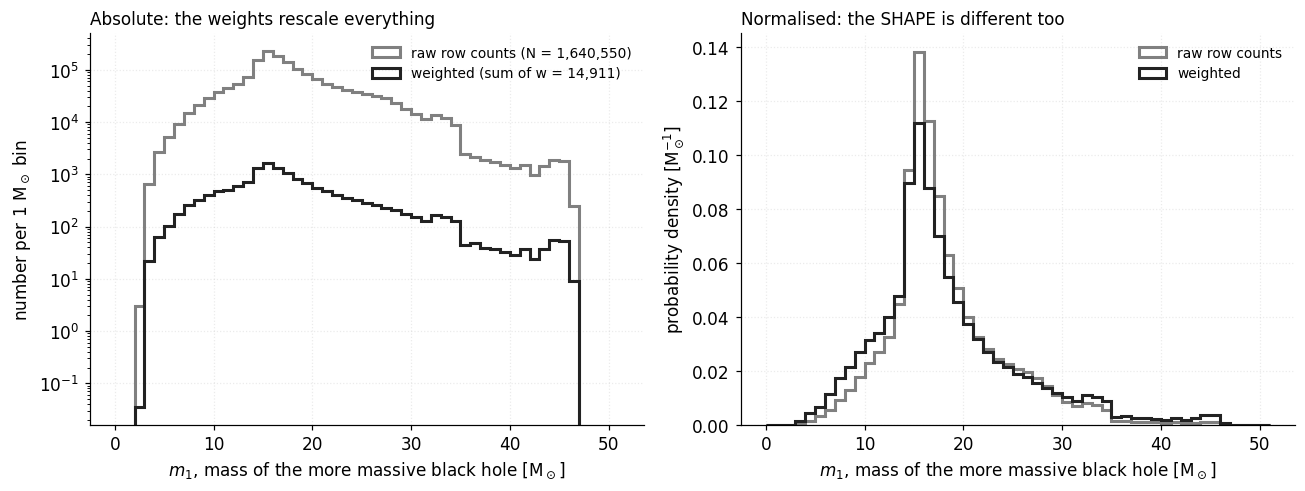

        mass range  counting rows  summing weights   error factor
------------------------------------------------------------------
      m1 < 10 Msun          5.06%            8.96%          0.56x
      10 < m1 < 20         67.10%           61.32%          1.09x
      20 < m1 < 30         23.05%           21.84%          1.06x
      m1 > 30 Msun          4.79%            7.88%          0.61x
      m1 > 40 Msun          0.56%            1.63%          0.34x

('summing weights' is the correct column; 'error factor' < 1 means counting rows UNDERSTATES that mass range)


In [6]:
bins = np.arange(0, 52, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# left: absolute numbers, so you can see how much smaller the weighted total is
axes[0].hist(bbh.m1, bins=bins, histtype="step", lw=2, color="grey",
             label=f"raw row counts (N = {len(bbh):,})")
axes[0].hist(bbh.m1, bins=bins, weights=bbh.w, histtype="step", lw=2, color=CSYS,
             label=f"weighted (sum of w = {bbh.w.sum():,.0f})")
axes[0].set_yscale("log")
axes[0].set_ylabel("number per 1 M$_\\odot$ bin")
axes[0].set_title("Absolute: the weights rescale everything", loc="left", fontsize=11)

# right: both normalised to unit area -- this is the comparison that matters
axes[1].hist(bbh.m1, bins=bins, density=True, histtype="step", lw=2, color="grey",
             label="raw row counts")
axes[1].hist(bbh.m1, bins=bins, weights=bbh.w, density=True, histtype="step", lw=2, color=CSYS,
             label="weighted")
axes[1].set_ylabel("probability density [M$_\\odot^{-1}$]")
axes[1].set_title("Normalised: the SHAPE is different too", loc="left", fontsize=11)

for ax in axes:
    ax.set_xlabel(r"$m_1$, mass of the more massive black hole [M$_\odot$]")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"{'mass range':>18s} {'counting rows':>14s} {'summing weights':>16s} {'error factor':>14s}")
print("-" * 66)
for label, m in [("m1 < 10 Msun", bbh.m1 < 10),
                 ("10 < m1 < 20", (bbh.m1 > 10) & (bbh.m1 < 20)),
                 ("20 < m1 < 30", (bbh.m1 > 20) & (bbh.m1 < 30)),
                 ("m1 > 30 Msun", bbh.m1 > 30),
                 ("m1 > 40 Msun", bbh.m1 > 40)]:
    raw = m.mean()
    wei = bbh.w[m].sum() / bbh.w.sum()
    print(f"{label:>18s} {100*raw:13.2f}% {100*wei:15.2f}% {raw/wei:13.2f}x")
print("\n('summing weights' is the correct column; 'error factor' < 1 means "
      "counting rows UNDERSTATES that mass range)")

**Look at what changed.** The two shapes are *not* the same. Counting rows piles too much of the
population into the 10–20 M$_\odot$ peak and **understates both tails** — by roughly a factor of two
at the light end, and by up to a factor of three above 40 M$_\odot$. The reason is the sampling
strategy: the adaptive sampler concentrated its raw *effort* where merging systems are easy to
find, and the weights are what put the rare tails back to their proper size.

If you had written a paper using the grey curve, your statement about how common the most massive
black holes are would have been **wrong by a factor of a few** — and the error would have been
completely invisible, because the grey curve looks perfectly reasonable on its own.

> ⚠️ Note that the sign of the effect is not something you can guess. Here the weights *raise* the
> tails; in another dataset, sampled differently, they might lower them. **You have to apply them
> and look.**

> 🧠 **The general lesson, worth more than this dataset:** whenever you use someone else's
> simulation, find out **how it was sampled** before you plot anything. If there is a weight
> column, there is a reason for it.

**From here on every histogram in this notebook uses `weights=bbh.w`.**

## 3.2 The mass distribution, and how to read it

Now the real plot. We show the distribution of the **more massive** black hole ($m_1$), the
**less massive** one ($m_2$), and **all black holes** regardless of which is which.

Two presentational choices worth copying:

- **Logarithmic $y$-axis.** The distribution spans several orders of magnitude; on a linear axis
  everything above ~25 M$_\odot$ would be an invisible flat line against the bottom.
- **Density normalisation** (`density=True`) so the $y$-axis is a
  [probability density](https://en.wikipedia.org/wiki/Probability_density_function) and does not
  depend on our choice of bin width.

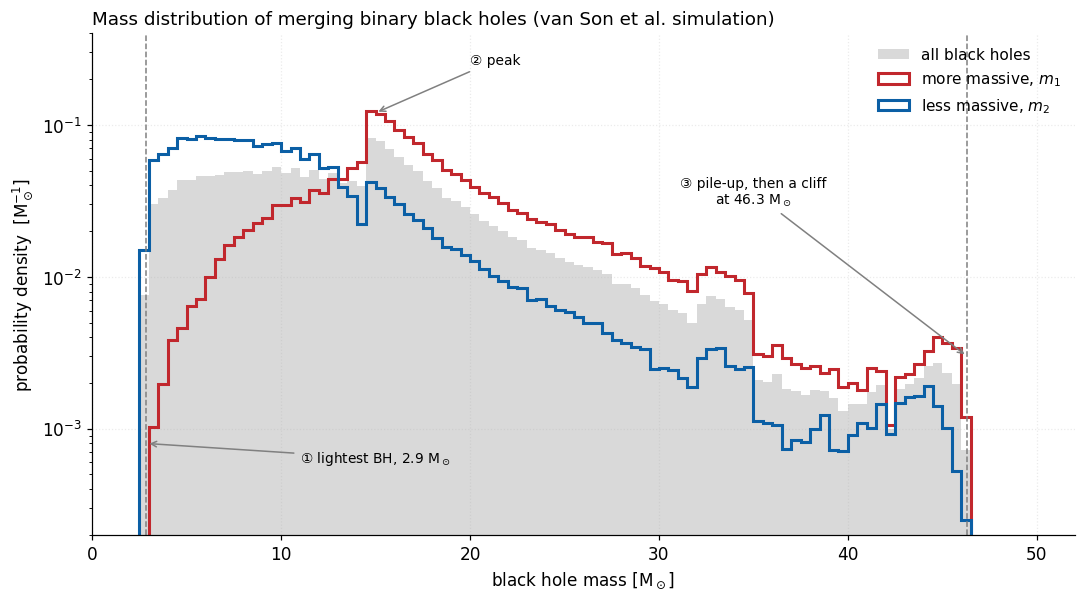

lightest black hole in the sample :   2.87 Msun
heaviest below the gap            :  46.30 Msun
weighted median of m1             :  16.60 Msun
weighted median of m2             :   9.46 Msun


In [7]:
bins = np.arange(0, 52, 0.5)
all_masses = np.concatenate([bbh.m1.values, bbh.m2.values])
all_weights = np.concatenate([bbh.w.values, bbh.w.values])

fig, ax = plt.subplots(figsize=(10, 5.6))

ax.hist(all_masses, bins=bins, weights=all_weights, density=True,
        histtype="stepfilled", color="0.85", edgecolor="none", label="all black holes")
ax.hist(bbh.m1, bins=bins, weights=bbh.w, density=True,
        histtype="step", lw=2, color=C1, label=r"more massive, $m_1$")
ax.hist(bbh.m2, bins=bins, weights=bbh.w, density=True,
        histtype="step", lw=2, color=C2, label=r"less massive, $m_2$")

ax.set_yscale("log")
ax.set_xlim(0, 52)
ax.set_ylim(2e-4, 0.4)   # clip the very lowest-density bins so the shape is readable
ax.set_xlabel(r"black hole mass [M$_\odot$]")
ax.set_ylabel(r"probability density  [M$_\odot^{-1}$]")
ax.set_title("Mass distribution of merging binary black holes (van Son et al. simulation)",
             loc="left", fontsize=12)
ax.legend(loc="upper right", fontsize=10)

# --- annotate the features we are about to discuss ------------------------------
m_min = all_masses.min()
m_max_below_gap = all_masses[all_masses < 100].max()
ax.axvline(m_min, color="grey", lw=1, ls="--")
ax.axvline(m_max_below_gap, color="grey", lw=1, ls="--")
ax.annotate(f"① lightest BH, {m_min:.1f} M$_\\odot$", xy=(m_min, 8e-4), xytext=(11, 6e-4),
            fontsize=9, ha="left", arrowprops=dict(arrowstyle="->", color="grey", lw=1))
ax.annotate("② peak", xy=(15, 0.12), xytext=(20, 0.25),
            fontsize=9, ha="left", arrowprops=dict(arrowstyle="->", color="grey", lw=1))
ax.annotate(f"③ pile-up, then a cliff\nat {m_max_below_gap:.1f} M$_\\odot$",
            xy=(m_max_below_gap, 3e-3), xytext=(35, 3e-2), fontsize=9, ha="center",
            arrowprops=dict(arrowstyle="->", color="grey", lw=1))

plt.tight_layout()
plt.show()

print(f"lightest black hole in the sample : {m_min:6.2f} Msun")
print(f"heaviest below the gap            : {m_max_below_gap:6.2f} Msun")
print(f"weighted median of m1             : {weighted_median(bbh.m1, bbh.w):6.2f} Msun")
print(f"weighted median of m2             : {weighted_median(bbh.m2, bbh.w):6.2f} Msun")

### 📖 Reading the features, one at a time

**① A hard lower edge at ~2.9 M$_\odot$.** No black hole in this simulation is lighter than that.
Below it, the code would have made a *neutron star* instead — and COMPAS caps neutron stars at
2.5 M$_\odot$. So this model contains a small **lower mass gap** between the heaviest neutron star
and the lightest black hole. Whether such a gap exists in nature is
[genuinely unsettled](https://en.wikipedia.org/wiki/Neutron_star#Mass_and_temperature) — it was
long claimed from X-ray binaries, and gravitational-wave events such as GW190814 (a ~2.6 M$_\odot$
object) have made it look less clear-cut. Here it is simply a **consequence of the prescription
the code was given**, not a discovery.

**② A broad peak around ~15 M$_\odot$, then a steady decline.** Most merging black holes are in the
10–20 M$_\odot$ range. This traces back to the birth mass function of stars: massive stars are
[much rarer than light ones](https://en.wikipedia.org/wiki/Initial_mass_function), so heavy black
holes are rare simply because their progenitors are rare.

You may also notice a **sharp step right at the peak**. Features that sharp are usually a
fingerprint of a *prescription* rather than of nature — here, of the recipe that maps a dying
star's core onto a remnant mass ([Fryer et al. 2012](https://arxiv.org/abs/1110.1726)), which has a
transition between "part of the star escapes" and "the whole star falls in". Treat such knife-edge
features with suspicion, and always ask whether they survive a change of prescription.

**③ A pile-up and then a *cliff* at ~46 M$_\odot$.** The distribution rises slightly just before it
stops dead. Nothing at all above it. **This is the most physically interesting feature in the whole
plot**, and it gets its own section.

## 3.3 The pair-instability supernova (PISN) mass gap 🚫

Let's establish the fact first, then explain it.

In [8]:
edges = np.arange(0, 200, 2.0)
counts, _ = np.histogram(all_masses, bins=edges, weights=all_weights)

occupied = edges[:-1][counts > 0]
print("Mass bins (2 Msun wide) that contain at least one black hole:")
print(f"   from {occupied.min():.0f} to {occupied[occupied < 100].max() + 2:.0f} Msun ... "
      f"then NOTHING ... then {occupied[occupied > 100].min():.0f} to {occupied.max() + 2:.0f} Msun")

gap = (all_masses > 50) & (all_masses < 120)
print(f"\nBlack holes with 50 < M < 120 Msun: {gap.sum()}  (weighted: {all_weights[gap].sum():.1f})")

above = all_masses > 120
print(f"Black holes above 120 Msun        : {above.sum()}  "
      f"(weighted: {all_weights[above].sum():.2f}, i.e. "
      f"{100*all_weights[above].sum()/all_weights.sum():.4f}% of all black holes)")
print(f"   their masses span {all_masses[above].min():.0f} - {all_masses[above].max():.0f} Msun")

Mass bins (2 Msun wide) that contain at least one black hole:
   from 2 to 48 Msun ... then NOTHING ... then 134 to 142 Msun

Black holes with 50 < M < 120 Msun: 0  (weighted: 0.0)
Black holes above 120 Msun        : 19  (weighted: 0.38, i.e. 0.0013% of all black holes)
   their masses span 135 - 141 Msun


### Why the gap is there

A star ends its life with a **helium core** — the burnt-out inner region left after hydrogen
fusion. What that core does when it runs out of fuel depends almost entirely on **how massive it
is**:

- **Small helium cores** collapse to a neutron star or a black hole in the ordinary way.
- **Helium cores between roughly 35 and 60 M$_\odot$** become so hot in the centre that the photons
  there carry enough energy to spontaneously convert into
  [electron–positron pairs](https://en.wikipedia.org/wiki/Pair_production). Photons provide the
  pressure holding the star up; turning them into particles **removes that pressure**, the core
  contracts, fusion runs away, and the star blows off its outer layers in a violent pulse. It then
  re-settles, and may pulse again. These are **pulsational pair-instability supernovae (PPISN)**.
  Each pulse throws away mass, so *whatever* mass the star started with, it arrives at collapse
  with roughly the same, capped mass. **That is the pile-up just below the cliff.**
- **Helium cores between roughly 60 and 130 M$_\odot$** do not merely pulse — the runaway fusion
  releases more energy than the star's gravitational binding energy, and the star is
  **completely disrupted**. Nothing is left behind at all: no neutron star, no black hole. This is
  a [**pair-instability supernova (PISN)**](https://en.wikipedia.org/wiki/Pair-instability_supernova).
  **That is why the gap is empty.**
- **Helium cores above ~130 M$_\odot$** are so massive that gravity wins anyway: photodisintegration
  sets in and the whole star collapses **directly** into a black hole, with no explosion. Those are
  the handful of very heavy black holes you just counted **above** the gap.

So the empty band is not a modelling accident — it is a **prediction of nuclear and particle
physics**, and it is one of the few places where stellar astrophysics makes a sharp, falsifiable
statement about black hole masses.

### Why you should care

The gap's edges are **relatively robust**: they are set by nuclear reaction rates rather than by
the messy, uncertain binary physics (common envelope, kicks, winds) that dominates most other
predictions. That makes the mass distribution's upper edge one of the best available probes of
stellar physics — and it is exactly the argument of
[van Son et al. (2023)](https://arxiv.org/abs/2209.03385).

> 🤔 **But it is not settled.** Observationally, LIGO's
> [GW190521](https://en.wikipedia.org/wiki/GW190521) had a primary black hole of ~85 M$_\odot$ —
> apparently *inside* the gap. Explanations range from "the reaction rates are off" to
> "it was a merger of two smaller black holes that merged again" (a *hierarchical* merger, which
> population synthesis of isolated binaries cannot produce by construction). Watch this space.

📖 Further reading, in increasing order of difficulty:
[Wikipedia: pair-instability supernova](https://en.wikipedia.org/wiki/Pair-instability_supernova) ·
[Wikipedia: GW190521](https://en.wikipedia.org/wiki/GW190521) ·
[Woosley (2017)](https://arxiv.org/abs/1608.08939) ·
[Farmer et al. (2019)](https://arxiv.org/abs/1910.12874)

## 3.4 Bonus: the chirp mass distribution

Before we move on, one more 1D plot. Gravitational-wave detectors measure the
[**chirp mass**](https://en.wikipedia.org/wiki/Chirp_mass)
$\mathcal{M}_c = (m_1 m_2)^{3/5} / (m_1+m_2)^{1/5}$ far more precisely than they measure $m_1$ and
$m_2$ separately, because it is the combination that sets how quickly the signal's frequency sweeps
upwards — the "chirp" that gives the quantity its name. So when you compare a model to data, the
chirp mass distribution is often the fairest comparison.

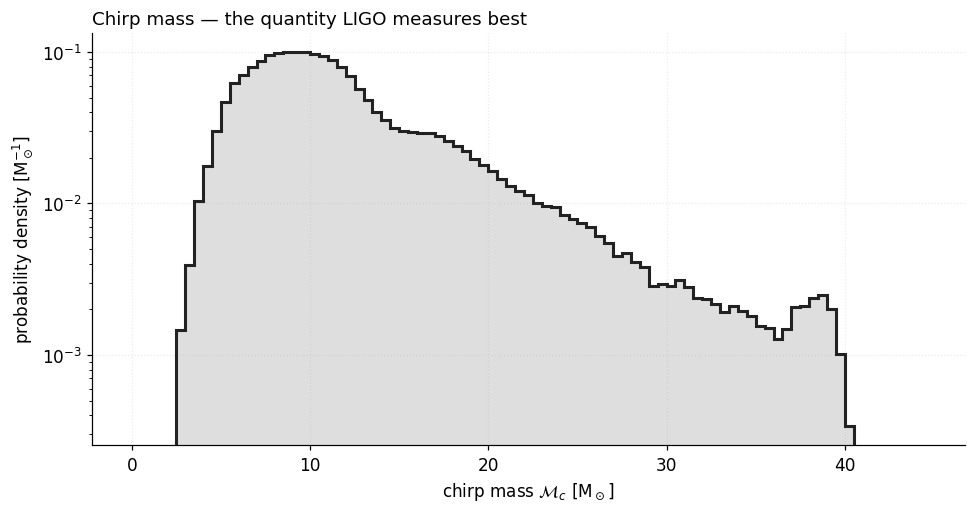

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(bbh.Mchirp, bins=np.arange(0, 45, 0.5), weights=bbh.w, density=True,
        histtype="stepfilled", color=CSYS, alpha=0.15)
ax.hist(bbh.Mchirp, bins=np.arange(0, 45, 0.5), weights=bbh.w, density=True,
        histtype="step", lw=2, color=CSYS)
ax.set_yscale("log")
ax.set_xlabel(r"chirp mass $\mathcal{M}_c$ [M$_\odot$]")
ax.set_ylabel(r"probability density [M$_\odot^{-1}$]")
ax.set_title("Chirp mass — the quantity LIGO measures best", loc="left", fontsize=12)
plt.tight_layout()
plt.show()

Notice that the chirp mass distribution is **shifted to lower values** than the $m_1$
distribution and is smoother. That is arithmetic, not physics: $\mathcal{M}_c$ is always smaller
than either component mass for unequal-mass systems, and averaging over the mass ratio washes out
sharp features. **A feature that is crisp in $m_1$ can be nearly invisible in $\mathcal{M}_c$** —
worth remembering when someone tells you a model does or does not match the data.

<a id="part4"></a>
# Part 4 — The 2D mass distribution: $m_1$ vs $m_2$

A 1D histogram throws away the *pairing*: it tells you how many 30 M$_\odot$ black holes there are,
but not what they are paired with. The 2D distribution keeps that information.

With 1.6 million points, a scatter plot would be a black smudge. We use
[`hexbin`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hexbin.html), which tiles
the plane with hexagons and colours each by the **summed weight** of the points inside it —
essentially a weighted 2D histogram. The colour scale is logarithmic, because the density spans
four orders of magnitude.

By construction $m_1 \ge m_2$, so **everything lies below the diagonal**. Points *on* the diagonal
are equal-mass twins.

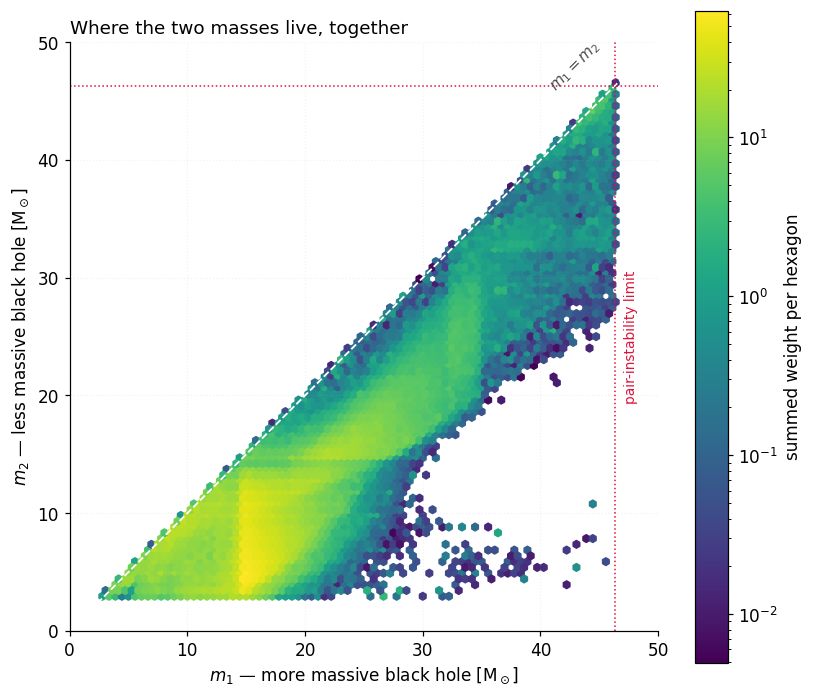

In [10]:
fig, ax = plt.subplots(figsize=(7.6, 6.6))

hb = ax.hexbin(bbh.m1, bbh.m2, C=bbh.w, reduce_C_function=np.sum,
               gridsize=90, extent=(0, 50, 0, 50), mincnt=1,
               norm=LogNorm(), cmap="viridis")
cb = fig.colorbar(hb, ax=ax)
cb.set_label("summed weight per hexagon")

ax.plot([0, 50], [0, 50], color="white", lw=1.2, ls="--")
ax.text(43, 46, r"$m_1 = m_2$", color="0.3", fontsize=10, ha="center", rotation=45)

# mark the pair-instability limit on both axes. NOTE: we use the heaviest BH *below*
# the gap, not bbh.m1.max() -- that would pick up the rare ~140 Msun above-gap systems.
m_lim = bbh.m1[bbh.m1 < 100].max()
ax.axvline(m_lim, color="crimson", lw=1, ls=":")
ax.axhline(m_lim, color="crimson", lw=1, ls=":")
ax.text(m_lim + 0.8, 25, "pair-instability limit", color="crimson", fontsize=9,
        rotation=90, va="center")

ax.set_xlabel(r"$m_1$ — more massive black hole [M$_\odot$]")
ax.set_ylabel(r"$m_2$ — less massive black hole [M$_\odot$]")
ax.set_title("Where the two masses live, together", loc="left", fontsize=12)
ax.set_xlim(0, 50)
ax.set_ylim(0, 50)
ax.set_aspect("equal")
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

### 📖 What to notice

- **The population hugs the diagonal.** Most merging binary black holes are *fairly* equal-mass.
  There are two reasons, and they compound: massive stars are usually born with a companion of
  similar mass, and mass transfer tends to push a binary *towards* equal masses (the accretor gains
  what the donor loses).
- **The bright core sits at $m_1 \approx 10$–$20$, $m_2 \approx 8$–$15$ M$_\odot$** — the same peak
  you saw in 1D, now located in both dimensions.
- **A hard corner at ~46 M$_\odot$ in *both* directions.** The pair-instability limit applies to
  each black hole independently, so the whole population is confined to a box. There is no
  smooth fall-off, just a wall.
- **A sparse "shelf" at low $m_2$** — systems with a fairly heavy $m_1$ (20–45 M$_\odot$) and a
  distinctly light $m_2$ (3–10 M$_\odot$). These are rare, very unequal binaries. Note how much
  clearer they are here than in the 1D plot, where they hid under the peak.
- **Faint internal ridges and steps** (e.g. a change of texture around 14 M$_\odot$ and again
  around 32–35 M$_\odot$). These are the same prescription fingerprints as in §3.2, now visible as
  lines in 2D. This is a general and useful fact: **2D distributions expose structure that 1D
  projections average away.**

<a id="part5"></a>
# Part 5 — Separation vs mass ratio: finding the islands 🏝️

Now the plot the whole notebook has been building towards.

## 5.1 A missing column, and how to get it back

We want the **orbital separation** at the moment the binary black hole formed. As we noticed in
§1.3, **it is not in the file.** Published datasets get trimmed; this is completely normal, and
learning to work around it is a real skill.

But we do have `Coalescence_Time` — how long the system takes to merge — and we know
[Peters' (1964)](https://journals.aps.org/pr/abstract/10.1103/PhysRev.136.B1224) formula from
§0.2 relating that to the separation. So we can simply **invert it**:

$$t_{\rm merge} = \frac{5}{256}\,\frac{c^5 a^4}{G^3 m_1 m_2 (m_1+m_2)}
\qquad\Longrightarrow\qquad
a = \left[\frac{256}{5}\,\frac{G^3\,m_1 m_2 (m_1+m_2)\,t_{\rm merge}}{c^5}\right]^{1/4}.$$

> ⚠️ **Be honest about your assumptions.** Peters' formula in this form assumes a **circular**
> orbit. Real binary black holes emerge from supernovae with some eccentricity, and an eccentric
> binary merges *faster* than a circular one of the same separation — so for eccentric systems our
> reconstructed $a$ is a slight **underestimate**. Most systems here are close to circular, so the
> picture is right; but if you needed the separations for a paper you would ask the authors for the
> real column rather than reconstructing it. **Say so in your figure caption when you do something
> like this.**

In [11]:
# SI constants -- no external dependencies needed
G_SI  = 6.67430e-11        # m^3 kg^-1 s^-2
C_SI  = 2.99792458e8       # m s^-1
MSUN  = 1.98892e30         # kg
RSUN  = 6.957e8            # m
MYR   = 3.15576e13         # s
GYR   = 3.15576e16         # s


def separation_from_merger_time(t_merge_Myr, m1_msun, m2_msun):
    '''Invert Peters (1964) for a circular orbit: given the time to merge, return a in Rsun.'''
    t  = np.asarray(t_merge_Myr) * MYR
    m1 = np.asarray(m1_msun) * MSUN
    m2 = np.asarray(m2_msun) * MSUN
    a_metres = (256.0 / 5.0 * G_SI**3 * m1 * m2 * (m1 + m2) * t / C_SI**5) ** 0.25
    return a_metres / RSUN


def merger_time_from_separation(a_rsun, m1_msun, m2_msun):
    '''The forward direction, for the sanity check below. Returns Myr.'''
    a  = np.asarray(a_rsun) * RSUN
    m1 = np.asarray(m1_msun) * MSUN
    m2 = np.asarray(m2_msun) * MSUN
    t_sec = 5.0 / 256.0 * C_SI**5 * a**4 / (G_SI**3 * m1 * m2 * (m1 + m2))
    return t_sec / MYR


bbh["a_Rsun"] = separation_from_merger_time(bbh.t_coal_Myr, bbh.m1, bbh.m2)
bbh["log_a"]  = np.log10(bbh.a_Rsun)

# --- sanity check: does the round trip give back what we started with? ----------
t_back = merger_time_from_separation(bbh.a_Rsun, bbh.m1, bbh.m2)
print(f"round-trip check, max relative error: "
      f"{np.max(np.abs(t_back - bbh.t_coal_Myr) / bbh.t_coal_Myr):.2e}   (should be ~0)")

print(f"\nreconstructed separations [Rsun]:")
for p in [0, 1, 25, 50, 75, 99, 100]:
    print(f"   {p:3d}th percentile : {np.percentile(bbh.a_Rsun, p):9.4f}")
print(f"\nFor scale: the Sun's radius is 1 Rsun, and the Earth-Sun distance is 215 Rsun.")
print(f"({(bbh.a_Rsun < 1).sum()} systems come out below 1 Rsun -- these are the rare binaries "
      f"that merge essentially\n instantly, and we will simply leave them off the left edge of "
      f"the plots below.)")

round-trip check, max relative error: 1.55e-15   (should be ~0)

reconstructed separations [Rsun]:
     0th percentile :    0.0044
     1th percentile :    3.1121
    25th percentile :    5.6602
    50th percentile :    8.7385
    75th percentile :   15.2947
    99th percentile :   41.8341
   100th percentile :   64.0785

For scale: the Sun's radius is 1 Rsun, and the Earth-Sun distance is 215 Rsun.
(280 systems come out below 1 Rsun -- these are the rare binaries that merge essentially
 instantly, and we will simply leave them off the left edge of the plots below.)


> 🔍 **Pause on those numbers.** These black holes are a few to a few tens of **solar radii** apart
> — closer than Mercury is to the Sun, and often *closer together than the stars they came from
> were wide*. That is the whole point of Notebook 1: something (a common envelope, or a long phase
> of stable mass transfer) had to shrink the orbit dramatically, or these systems would never merge.

## 5.2 The plot: $\log_{10} a$ vs $q$

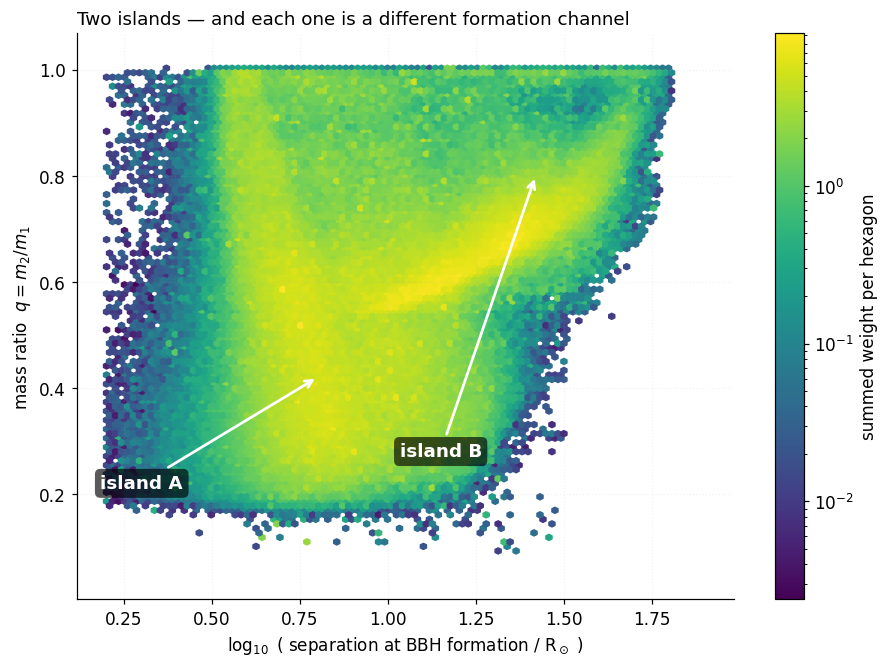

In [12]:
fig, ax = plt.subplots(figsize=(8.4, 6.2))

hb = ax.hexbin(bbh.log_a, bbh.q, C=bbh.w, reduce_C_function=np.sum,
               gridsize=100, extent=(0.2, 1.9, 0.05, 1.02), mincnt=1,
               norm=LogNorm(), cmap="viridis")
cb = fig.colorbar(hb, ax=ax)
cb.set_label("summed weight per hexagon")

# point out the two concentrations discussed in the text
for xy, label, xytext in [((0.80, 0.42), "island A", (0.30, 0.22)),
                          ((1.42, 0.80), "island B", (1.15, 0.28))]:
    ax.annotate(label, xy=xy, xytext=xytext, fontsize=12, color="white", weight="bold",
                ha="center", va="center",
                bbox=dict(boxstyle="round,pad=0.3", fc="black", ec="none", alpha=0.65),
                arrowprops=dict(arrowstyle="->", color="white", lw=1.8))

ax.set_xlabel(r"$\log_{10}$ ( separation at BBH formation / R$_\odot$ )")
ax.set_ylabel(r"mass ratio  $q = m_2/m_1$")
ax.set_title("Two islands — and each one is a different formation channel", loc="left", fontsize=12)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

### 🏝️ There are two islands. Look again.

Squint at that plot and you should see **two overlapping but distinct concentrations**:

- **Island A** — a broad blob at $\log_{10}a \approx 0.5$–$1.2$ (i.e. $a \approx 3$–$16$ R$_\odot$),
  spanning a wide range of mass ratios, with plenty of very unequal systems down to $q \approx 0.2$.
- **Island B** — a narrower **diagonal ridge** running from about $(\log_{10}a,\,q) \approx
  (0.9,\,0.55)$ up to $(1.6,\,0.9)$: **wider** orbits, and **more equal** masses.

There is also a visible **notch** between them at intermediate $q$, and a sharp outer boundary on
the right-hand side.

Before reading on: **what could physically make two separate islands?** Write down a guess. Then
run the next cell, which colours the same plot by a single column from the data file.

- Different binary evolutionary pathways can lead initially very similar stars to two different BBH end states, thus leaving two independent population concentrations in the \(a-q\) parameter space.

In [13]:
# CE_Event_Counter: how many common-envelope events the binary went through.
print(bbh.groupby("n_CE").agg(
    rows=("n_CE", "size"),
    weighted=("w", "sum"),
).assign(weighted_pct=lambda d: 100 * d.weighted / d.weighted.sum()).round(1))

ce_mask  = bbh.n_CE >= 1      # went through at least one common envelope
smt_mask = bbh.n_CE == 0      # never had one: only stable mass transfer

         rows  weighted  weighted_pct
n_CE                                 
0      452787    4106.4          27.5
1     1180083   10520.0          70.6
2        7680     284.7           1.9


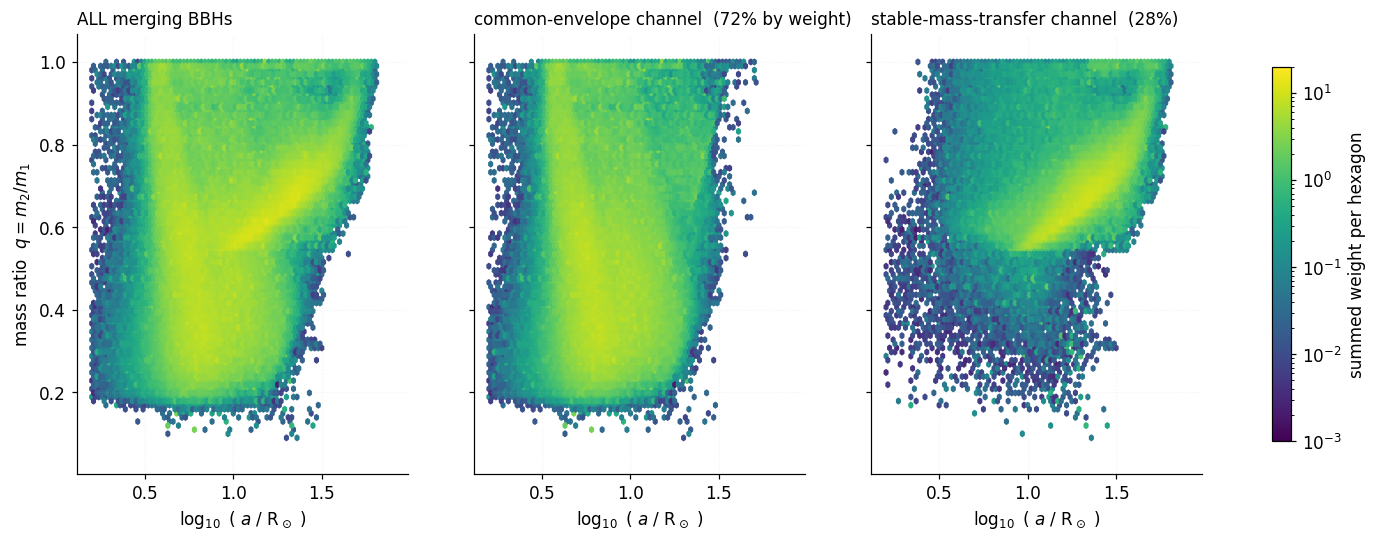

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2), sharex=True, sharey=True)

# The SAME colour map and the SAME normalisation in all three panels, so that equal
# colour means equal weight and the panels can honestly be compared by eye.
panels = [
    (bbh, "ALL merging BBHs"),
    (bbh[ce_mask],  f"common-envelope channel  ({100*bbh.w[ce_mask].sum()/bbh.w.sum():.0f}% by weight)"),
    (bbh[smt_mask], f"stable-mass-transfer channel  ({100*bbh.w[smt_mask].sum()/bbh.w.sum():.0f}%)"),
]

for ax, (d, title) in zip(axes, panels):
    hb = ax.hexbin(d.log_a, d.q, C=d.w, reduce_C_function=np.sum,
                   gridsize=85, extent=(0.2, 1.9, 0.05, 1.02), mincnt=1,
                   norm=LogNorm(vmin=1e-3, vmax=20), cmap="viridis")
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_xlabel(r"$\log_{10}$ ( $a$ / R$_\odot$ )")
    ax.grid(alpha=0.15)

axes[0].set_ylabel(r"mass ratio  $q = m_2/m_1$")
fig.colorbar(hb, ax=axes, shrink=0.85, label="summed weight per hexagon")
plt.show()

### 🎉 The islands are formation channels

One column — `CE_Event_Counter` — splits the population cleanly in two.

**Island A = the common-envelope (CE) channel.** At some point mass transfer became unstable, the
donor's envelope swallowed its companion, and drag inside that shared envelope dragged the two
cores together (Notebook 1, §0.5). A common envelope is a **violent, efficient orbital crusher** —
it can shrink a separation by a factor of a hundred or more in a few hundred days. So this channel
delivers systems at **small separations**. It also happens preferentially when the two stars are
*unlike* each other — a big evolved donor and a compact companion — which is why it populates
**low mass ratios**.

**Island B = the stable-mass-transfer (SMT) channel.** No common envelope ever happened. Instead
the binary shrank through one or more episodes of *stable*
[Roche-lobe overflow](https://en.wikipedia.org/wiki/Roche_lobe): slower, gentler, and much less
efficient at shrinking the orbit. So these systems end up at **wider separations** — and because
stable mass transfer moves material from the donor onto the accretor over a long time, it
**equalises the two masses**, pushing $q$ towards 1. Hence the diagonal ridge at high $q$.

**And why the diagonal?** Because these two facts are linked by the Hubble-time cut. A wider binary
only merges in time if it radiates gravitational waves efficiently, and — from Peters' formula —
that means it needs a **large $m_1 m_2 (m_1+m_2)$**, i.e. heavy *and* comparable masses. So as you
move right (wider), only increasingly equal-mass systems survive the cut. The **sharp outer
boundary on the right of the plot is literally the "merges within a Hubble time" selection**
drawn in these coordinates.

Let's check the mass claim directly, since it is the headline result of
[van Son et al. (2022)](https://arxiv.org/abs/2110.01634).

In [15]:
# weighted_median() was defined back in section 1.2 -- reusing it here
print(f"{'channel':28s} {'weight %':>9s} {'med m1':>8s} {'med q':>7s} "
      f"{'med a [Rsun]':>13s} {'med delay [Myr]':>16s}")
print("-" * 86)
for name, m in [("common envelope", ce_mask), ("stable mass transfer", smt_mask)]:
    d = bbh[m]
    print(f"{name:28s} {100*d.w.sum()/bbh.w.sum():8.1f}% "
          f"{weighted_median(d.m1, d.w):8.1f} {weighted_median(d.q, d.w):7.2f} "
          f"{weighted_median(d.a_Rsun, d.w):13.1f} "
          f"{weighted_median(d.t_form_Myr + d.t_coal_Myr, d.w):16.0f}")

print()
heavy, light = bbh.m1 > 30, bbh.m1 < 30
print(f"Of black holes with m1 > 30 Msun, "
      f"{100*bbh.w[smt_mask & heavy].sum()/bbh.w[heavy].sum():.0f}% come from stable mass transfer.")
print(f"Of black holes with m1 < 30 Msun, "
      f"{100*bbh.w[ce_mask & light].sum()/bbh.w[light].sum():.0f}% come from the common-envelope channel.")

channel                       weight %   med m1   med q  med a [Rsun]  med delay [Myr]
--------------------------------------------------------------------------------------
common envelope                  72.5%     15.7    0.53           7.1              175
stable mass transfer             27.5%     24.4    0.70          19.7             1856

Of black holes with m1 > 30 Msun, 79% come from stable mass transfer.
Of black holes with m1 < 30 Msun, 77% come from the common-envelope channel.


That is exactly the result of van Son et al. (2022):

> *"the CE channel preferentially produces BHs with masses below about 30 M$_\odot$ and short delay
> times, while the stable RLOF channel primarily forms systems with BH masses above 30 M$_\odot$ and
> long delay times."*

You just rediscovered it from the raw data, in about ten lines of code. 🎓

**Why does the split matter?** Because the two channels depend on *completely different* uncertain
physics. The common-envelope channel's yield hinges on the common-envelope efficiency parameters
$\alpha$ and $\lambda$ — arguably the most uncertain numbers in binary astrophysics. The stable
channel instead hinges on mass-transfer stability criteria and accretion efficiency. If you observe
that the heavy and light ends of the black hole mass distribution behave differently, you are
learning about *different physics* at each end. Mapping precisely that kind of model dependence is
what GROWL exists to do.

## 5.3 The same split, seen in the mass ratio alone

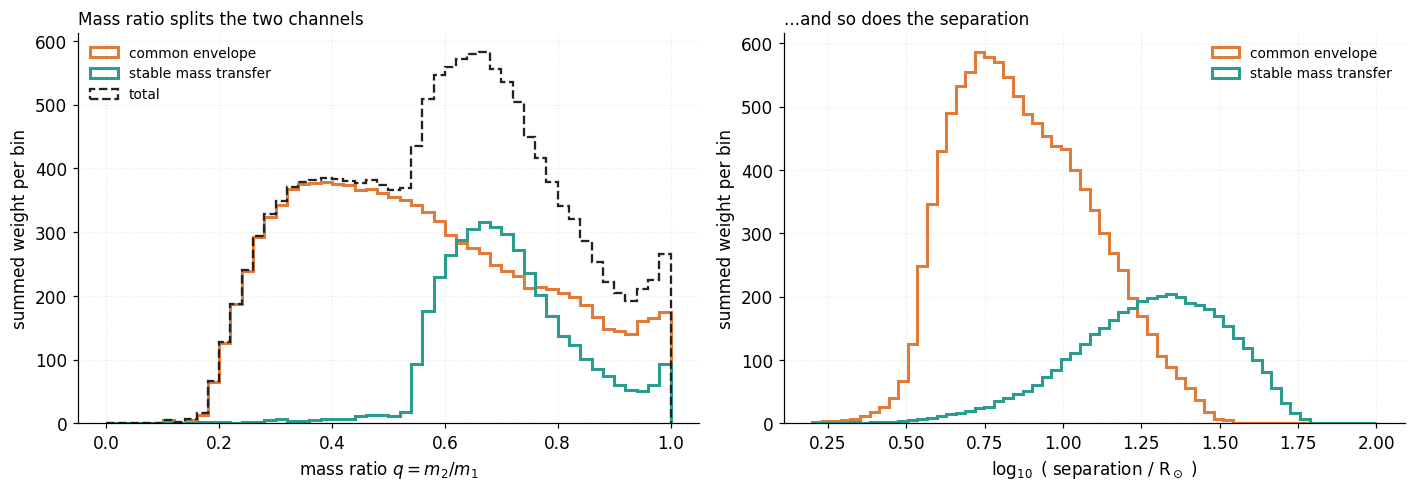

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

qbins = np.linspace(0, 1, 51)
for name, m, col in [("common envelope", ce_mask, C_CE),
                     ("stable mass transfer", smt_mask, C_SMT)]:
    axes[0].hist(bbh.q[m], bins=qbins, weights=bbh.w[m], histtype="step", lw=2,
                 color=col, label=name)
axes[0].hist(bbh.q, bins=qbins, weights=bbh.w, histtype="step", lw=1.5, color=CSYS,
             ls="--", label="total")
axes[0].set_xlabel(r"mass ratio $q = m_2/m_1$")
axes[0].set_ylabel("summed weight per bin")
axes[0].set_title("Mass ratio splits the two channels", loc="left", fontsize=11)
axes[0].legend(fontsize=9)

abins = np.linspace(0.2, 2.0, 60)
for name, m, col in [("common envelope", ce_mask, C_CE),
                     ("stable mass transfer", smt_mask, C_SMT)]:
    axes[1].hist(bbh.log_a[m], bins=abins, weights=bbh.w[m], histtype="step", lw=2,
                 color=col, label=name)
axes[1].set_xlabel(r"$\log_{10}$ ( separation / R$_\odot$ )")
axes[1].set_ylabel("summed weight per bin")
axes[1].set_title("...and so does the separation", loc="left", fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

Two clean, well-separated peaks in mass ratio: the common-envelope channel peaks near $q \approx
0.4$, the stable channel near $q \approx 0.7$. **The dashed total is bimodal** — and if you had only
the black dashed curve, with no knowledge of the channels, the bimodality would be a genuine puzzle.

This is the general shape of the argument that runs through the whole field: *a feature in an
observable distribution is a clue about which formation channel dominates.* Real gravitational-wave
catalogues are now just about large enough to start playing this game for real.

<a id="part6"></a>
# Part 6 — Bonus: metallicity, the master variable

In Notebook 1 we claimed that **metallicity controls black hole masses**: fewer metals → weaker
[stellar winds](https://en.wikipedia.org/wiki/Stellar_wind) → the star keeps more of its mass →
a heavier black hole. This dataset spans $Z$ from 0.0001 to 0.03 (a factor of 300, from
extremely metal-poor to well above solar), so we can just *look*.

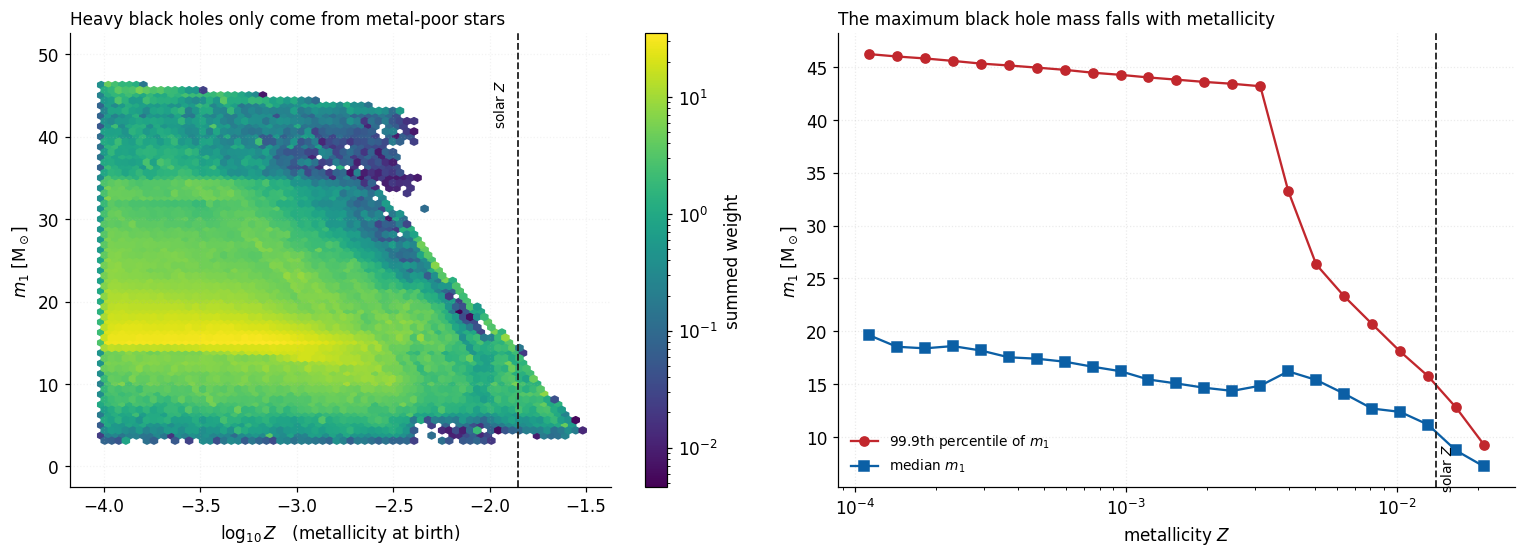

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# --- left: the full 2D density ---------------------------------------------------
ax = axes[0]
hb = ax.hexbin(np.log10(bbh.Z), bbh.m1, C=bbh.w, reduce_C_function=np.sum,
               gridsize=70, extent=(-4.05, -1.5, 0, 50), mincnt=1,
               norm=LogNorm(), cmap="viridis")
fig.colorbar(hb, ax=ax, label="summed weight")
ax.axvline(np.log10(0.014), color=CSYS, lw=1.2, ls="--")
ax.text(np.log10(0.014) - 0.05, 47, "solar $Z$", rotation=90, fontsize=9, ha="right", va="top")
ax.set_xlabel(r"$\log_{10} Z$   (metallicity at birth)")
ax.set_ylabel(r"$m_1$ [M$_\odot$]")
ax.set_title("Heavy black holes only come from metal-poor stars", loc="left", fontsize=11)
ax.grid(alpha=0.15)

# --- right: the maximum BH mass per metallicity bin ------------------------------
ax = axes[1]
zbins = np.logspace(-4, np.log10(0.03), 25)
zc, mmax, mmed = [], [], []
for lo, hi in zip(zbins[:-1], zbins[1:]):
    m = (bbh.Z >= lo) & (bbh.Z < hi) & (bbh.w > 0.01)   # drop the very lowest-weight outliers
    if m.sum() > 100:
        zc.append(np.sqrt(lo * hi))
        mmax.append(np.percentile(bbh.m1[m], 99.9))
        mmed.append(weighted_median(bbh.m1[m], bbh.w[m]))

ax.plot(zc, mmax, "o-", color=C1, label="99.9th percentile of $m_1$")
ax.plot(zc, mmed, "s-", color=C2, label="median $m_1$")
ax.set_xscale("log")
ax.axvline(0.014, color=CSYS, lw=1.2, ls="--")
ax.text(0.0145, 5, "solar $Z$", rotation=90, fontsize=9)
ax.set_xlabel(r"metallicity $Z$")
ax.set_ylabel(r"$m_1$ [M$_\odot$]")
ax.set_title("The maximum black hole mass falls with metallicity", loc="left", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 📖 What to notice

- The **upper envelope drops steeply** with metallicity. At $Z \lesssim 10^{-3}$ black holes reach
  the pair-instability limit at ~46 M$_\odot$; at $Z$ above solar the heaviest merging black hole in
  the whole simulation is barely 17 M$_\odot$. Winds are the reason — and because winds are driven
  by photons pushing on *metal* ions, their strength scales roughly as a power of $Z$.
- The **median** mass moves much less than the maximum. Metallicity mostly cuts off the top of the
  distribution rather than shifting the bulk.
- 💡 **This is why the metallicity history of the Universe matters so much for LIGO.** Heavy black
  holes require metal-poor star formation, which happened mostly at *high redshift* — long ago and
  far away. Connecting the two is precisely the job of cosmic integration.

<a id="exercises"></a>
# Part 7 — Your turn 🎓

These exercises are the point of the notebook. Bring your plots and questions to the next
onboarding session.

### Exercise 1 — The total mass distribution (warm-up, required)

Plot the weighted distribution of the **total mass** $M_{\rm tot} = m_1 + m_2$ of merging binary
black holes (the column `Mtot` already exists). Where does it cut off, and does that cutoff sit
where you expect given the pair-instability limit on each component? Is the cut as sharp as the
one in $m_1$? Explain why or why not.

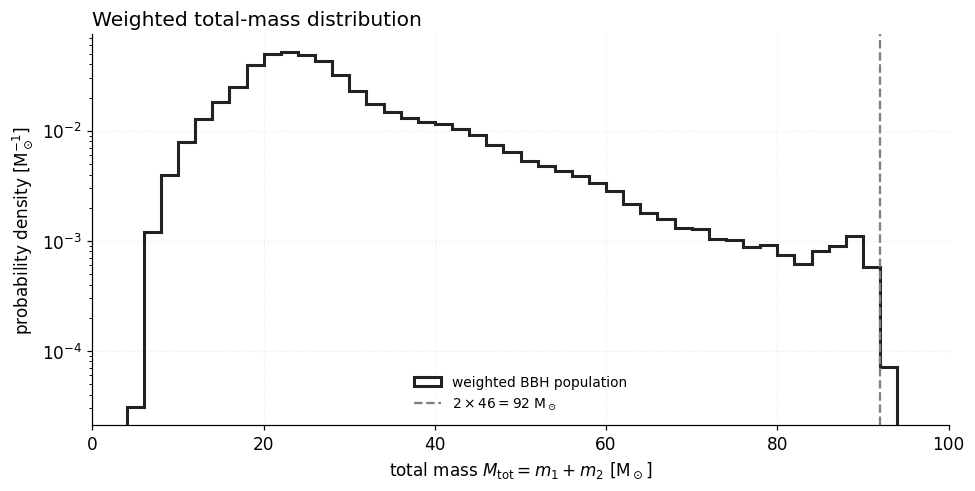

In [18]:
# --- Exercise 1 ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.6))

bins = np.arange(0, 102, 2.0)
ax.hist(bbh.Mtot, bins=bins, weights=bbh.w, density=True,
        histtype="step", lw=2, color=CSYS, label="weighted BBH population")

# Each first-generation component is capped near 46 solar masses by PPISN/PISN.
component_limit = 46
ax.axvline(2 * component_limit, color="grey", ls="--", lw=1.5,
           label=r"$2 \times 46 = 92$ M$_\odot$")

ax.set_xlabel(r"total mass $M_{\rm tot} = m_1 + m_2$ [M$_\odot$]")
ax.set_ylabel(r"probability density [M$_\odot^{-1}$]")
ax.set_yscale("log")
ax.set_xlim(0, 100)
ax.set_title("Weighted total-mass distribution", loc="left")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation.** The distribution ends near $M_{\rm tot} \simeq 92$ M$_\odot$, as expected: PPISN/PISN caps each first-generation black hole at about $46$ M$_\odot$, so two such components can total at most roughly $2 \times 46$ M$_\odot$. The approach to that endpoint is less cliff-like than the cutoff in $m_1$. A total mass near the limit requires *both* components to lie near their individual limits, which is rare, while many different $(m_1,m_2)$ pairs contribute to every lower total-mass bin. Summing over the distribution of mass ratios therefore spreads the component-mass edge into a declining tail, although the final boundary near $92$ M$_\odot$ remains hard in this isolated, first-generation population.


### Exercise 2 — Delay times

The **delay time** is the total time between the birth of the two stars and their merger:
`t_form_Myr + t_coal_Myr`.

1. Plot its weighted distribution, with **log axes on both** (delay times span from a few Myr to
   more than a Hubble time).
2. Overplot the two channels separately. Which one merges sooner, and does that match what you
   learned in Part 5 about their separations?
3. Theory predicts the delay time distribution should roughly follow a power law $\propto t^{-1}$.
   Add a $t^{-1}$ line to your plot and see how well it does.

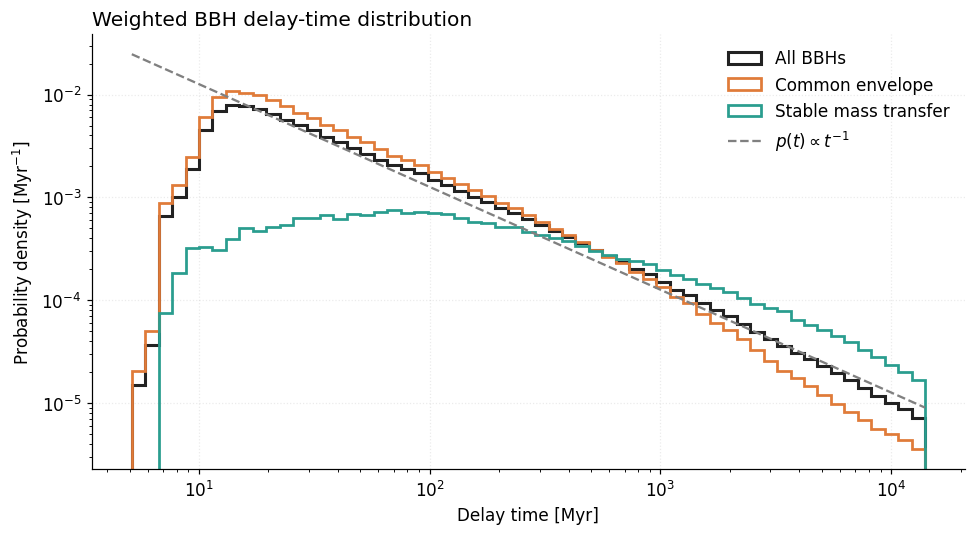

In [19]:
# --- Exercise 2 ------------------------------------------------------------------
# Total delay time: stellar formation + BBH coalescence
bbh["t_delay_Myr"] = bbh.t_form_Myr + bbh.t_coal_Myr

# Formation-channel masks (already defined earlier, but repeated for clarity)
ce_mask = bbh.n_CE >= 1
smt_mask = bbh.n_CE == 0

# Log-spaced bins are required for a logarithmic x-axis
t_min = bbh.t_delay_Myr.min()
t_max = bbh.t_delay_Myr.max()
bins = np.logspace(np.log10(t_min), np.log10(t_max), 60)

fig, ax = plt.subplots(figsize=(9, 5))

# Weighted distributions
ax.hist(
    bbh.t_delay_Myr,
    bins=bins,
    weights=bbh.w,
    density=True,
    histtype="step",
    lw=2,
    color=CSYS,
    label="All BBHs",
)

ax.hist(
    bbh.loc[ce_mask, "t_delay_Myr"],
    bins=bins,
    weights=bbh.loc[ce_mask, "w"],
    density=True,
    histtype="step",
    lw=1.8,
    color=C_CE,
    label="Common envelope",
)

ax.hist(
    bbh.loc[smt_mask, "t_delay_Myr"],
    bins=bins,
    weights=bbh.loc[smt_mask, "w"],
    density=True,
    histtype="step",
    lw=1.8,
    color=C_SMT,
    label="Stable mass transfer",
)

# Normalized p(t) ∝ 1/t reference line
t_line = np.logspace(np.log10(t_min), np.log10(t_max), 300)
p_line = 1 / (t_line * np.log(t_max / t_min))

ax.plot(
    t_line,
    p_line,
    color="grey",
    ls="--",
    lw=1.5,
    label=r"$p(t)\propto t^{-1}$",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Delay time [Myr]")
ax.set_ylabel(r"Probability density [Myr$^{-1}$]")
ax.set_title("Weighted BBH delay-time distribution", loc="left")
ax.legend()

plt.tight_layout()
plt.show()

### Exercise 3 — Do neutron stars show a mass gap too?

We threw away every system that was not a binary black hole. Go back to the full `dco` table and
plot the mass distribution of the **neutron stars** (`type == 13`).

- What is the maximum neutron star mass in this model, and does it look like a physical prediction
  or an imposed ceiling?
- Is there a gap between the heaviest neutron star and the lightest black hole? (This is the
  "lower mass gap" of §3.2 — a genuinely open question in the field.)
- How does the black hole mass distribution in **black hole–neutron star** binaries compare to the
  one in binary black holes? Should they be the same? *(Hint: think about which stars have to
  survive which supernovae. This is the subject of
  [van Son et al. 2022, *"No peaks without valleys"*](https://arxiv.org/abs/2209.13609).)*

Number of NSs: 255082
Maximum NS mass: 2.4999803609169766


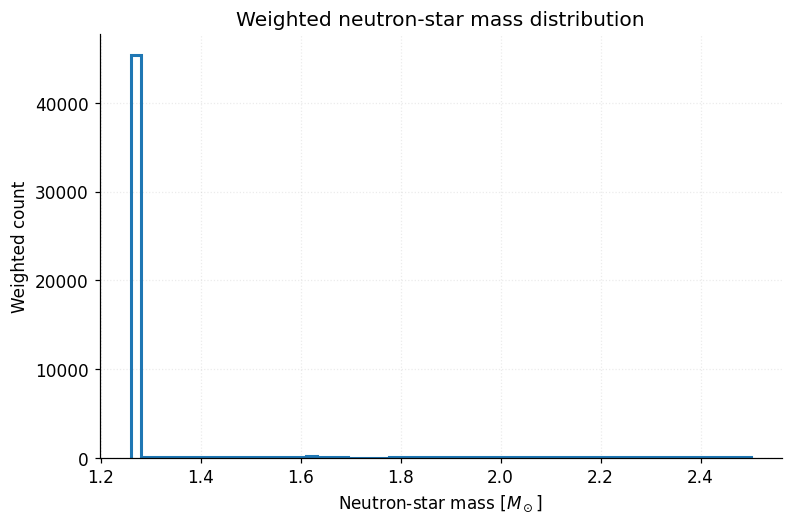

In [20]:
ns1 = dco.loc[dco["type1"] == 13, ["M1_raw", "w"]].copy()
ns1.columns = ["mass", "w"]

ns2 = dco.loc[dco["type2"] == 13, ["M2_raw", "w"]].copy()
ns2.columns = ["mass", "w"]

ns = pd.concat([ns1, ns2], ignore_index=True)

print("Number of NSs:", len(ns))
print("Maximum NS mass:", ns["mass"].max())

plt.figure(figsize=(8, 5))
plt.hist(
    ns["mass"],
    bins=60,
    weights=ns["w"],
    histtype="step",
    linewidth=2
)

plt.xlabel(r"Neutron-star mass [$M_\odot$]")
plt.ylabel("Weighted count")
plt.title("Weighted neutron-star mass distribution")
plt.show()

In [21]:
bh1 = dco.loc[dco["type1"] == 14, ["M1_raw", "w"]].copy()
bh1.columns = ["mass", "w"]

bh2 = dco.loc[dco["type2"] == 14, ["M2_raw", "w"]].copy()
bh2.columns = ["mass", "w"]

bh = pd.concat([bh1, bh2], ignore_index=True)

max_ns = ns["mass"].max()
min_bh = bh["mass"].min()

print(f"Heaviest NS: {max_ns:.3f} Msun")
print(f"Lightest BH: {min_bh:.3f} Msun")
print(f"Difference:  {min_bh - max_ns:.3f} Msun")

Heaviest NS: 2.500 Msun
Lightest BH: 2.869 Msun
Difference:  0.369 Msun


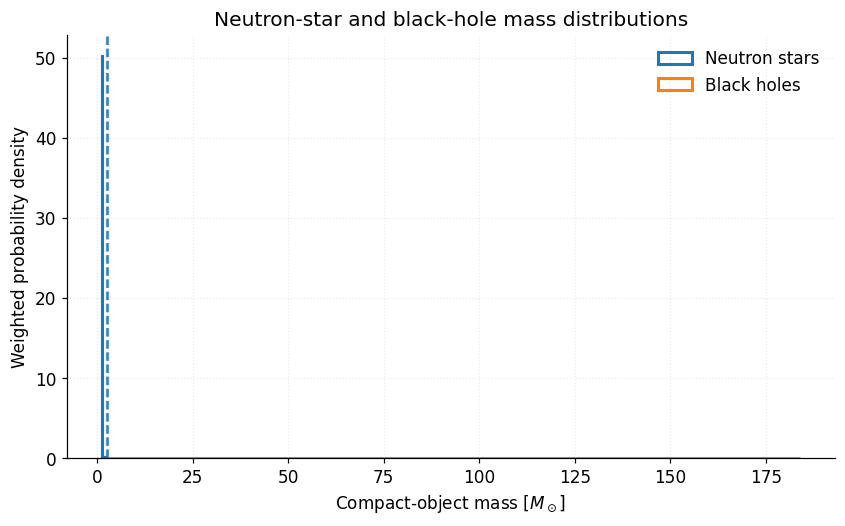

In [22]:
plt.figure(figsize=(9, 5))

plt.hist(
    ns["mass"],
    bins=70,
    weights=ns["w"],
    density=True,
    histtype="step",
    linewidth=2,
    label="Neutron stars"
)

plt.hist(
    bh["mass"],
    bins=100,
    weights=bh["w"],
    density=True,
    histtype="step",
    linewidth=2,
    label="Black holes"
)

plt.axvline(max_ns, linestyle="--", alpha=0.7)
plt.axvline(min_bh, linestyle="--", alpha=0.7)

plt.xlabel(r"Compact-object mass [$M_\odot$]")
plt.ylabel("Weighted probability density")
plt.title("Neutron-star and black-hole mass distributions")
plt.legend()
plt.show()

In this model, the maximum neutron-star mass is 2.500 Msun.; the lightest black hole has a mass of 2.869 Msun, leaving a narrow lower mass gap of about 0.369 Msun.

In [23]:
# Binary black holes
bbh = dco[
    (dco["type1"] == 14) &
    (dco["type2"] == 14)
].copy()

# Black-hole neutron-star binaries
bhns = dco[
    ((dco["type1"] == 14) & (dco["type2"] == 13)) |
    ((dco["type1"] == 13) & (dco["type2"] == 14))
].copy()

print("BBH rows:", len(bbh))
print("BHNS rows:", len(bhns))

BBH rows: 2273376
BHNS rows: 244410


In [24]:
bbh_bh1 = bbh[["M1_raw", "w"]].copy()
bbh_bh1.columns = ["mass", "w"]

bbh_bh2 = bbh[["M2_raw", "w"]].copy()
bbh_bh2.columns = ["mass", "w"]

bbh_bh = pd.concat([bbh_bh1, bbh_bh2], ignore_index=True)

bhns_bh1 = bhns.loc[
    bhns["type1"] == 14,
    ["M1_raw", "w"]
].copy()
bhns_bh1.columns = ["mass", "w"]

bhns_bh2 = bhns.loc[
    bhns["type2"] == 14,
    ["M2_raw", "w"]
].copy()
bhns_bh2.columns = ["mass", "w"]

bhns_bh = pd.concat([bhns_bh1, bhns_bh2], ignore_index=True)

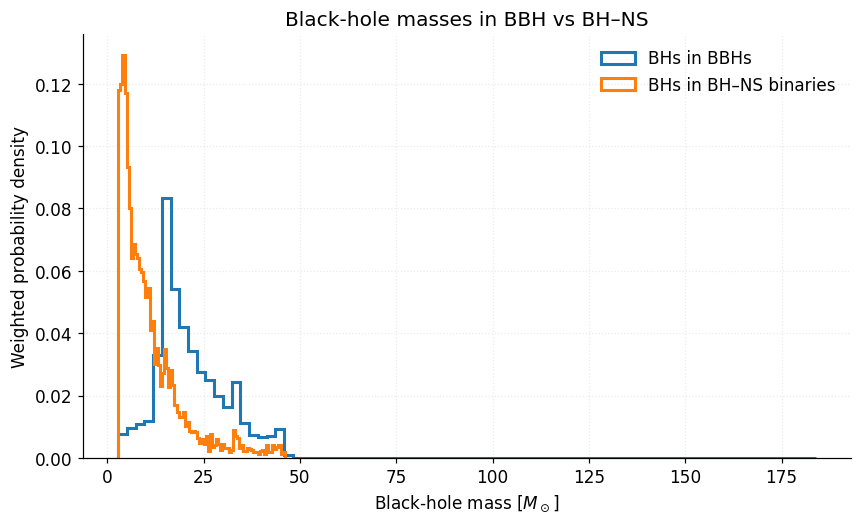

In [25]:
plt.figure(figsize=(9, 5))

plt.hist(
    bbh_bh["mass"],
    bins=80,
    weights=bbh_bh["w"],
    density=True,
    histtype="step",
    linewidth=2,
    label="BHs in BBHs"
)

plt.hist(
    bhns_bh["mass"],
    bins=80,
    weights=bhns_bh["w"],
    density=True,
    histtype="step",
    linewidth=2,
    label="BHs in BH–NS binaries"
)

plt.xlabel(r"Black-hole mass [$M_\odot$]")
plt.ylabel("Weighted probability density")
plt.title("Black-hole masses in BBH vs BH–NS")
plt.legend()
plt.show()

The black holes in BH–NS binaries are shifted toward lower masses compared with black holes in BBHs, whereas the BBH distribution peaks around 15- 20 Msun and extends to much larger masses. The two distributions are not expected to be identical because producing and retaining a BH–NS system requires a different mass-transfer history and survival of a neutron-star-forming supernova, including its mass loss and natal kick.

### Exercise 4 — Break the weights on purpose

Reproduce the Part 5 three-panel figure **without** the weights (drop `C=` and
`reduce_C_function=` from the `hexbin` calls, so it just counts rows). Does the two-island structure
survive? Does the *relative importance* of the two channels change? Write two sentences on what you
would have concluded from the unweighted version, and whether it would have been wrong.

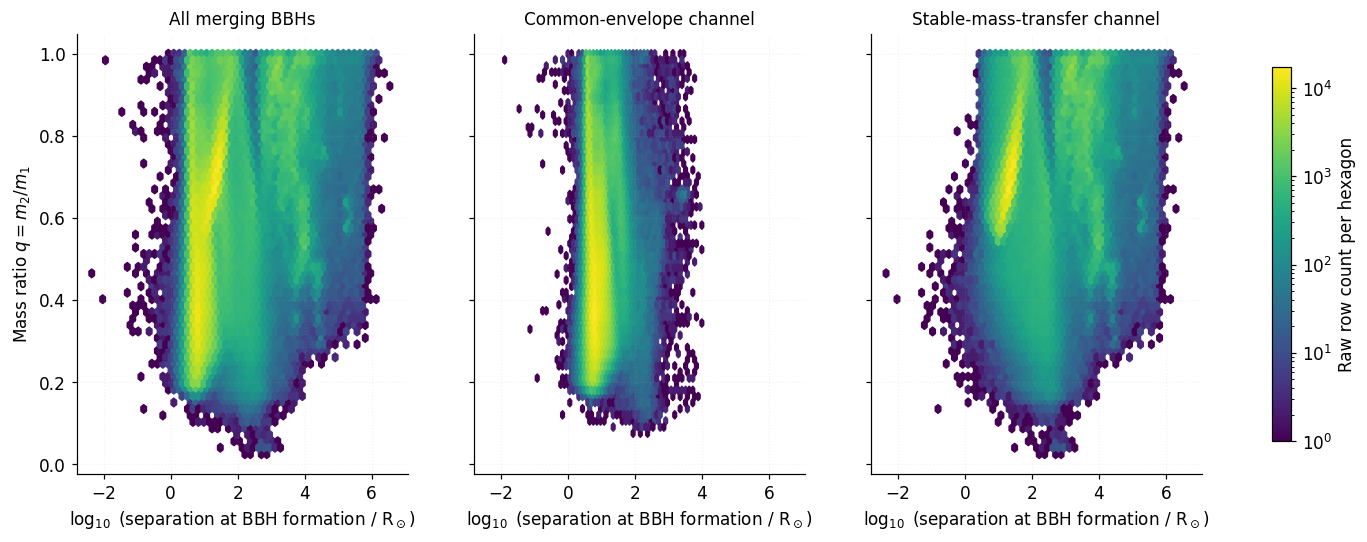

In [26]:
# Formation-channel masks
# Reconstruct the BBH separation if the Part 5 setup cell was not run.
if "log_a" not in bbh.columns:
    G_SI, C_SI = 6.67430e-11, 2.99792458e8
    MSUN, RSUN, MYR = 1.98892e30, 6.957e8, 3.15576e13
    t = bbh.t_coal_Myr.to_numpy() * MYR
    m1 = bbh.m1.to_numpy() * MSUN
    m2 = bbh.m2.to_numpy() * MSUN
    a_metres = (256 / 5 * G_SI**3 * m1 * m2 * (m1 + m2) * t / C_SI**5) ** 0.25
    bbh["a_Rsun"] = a_metres / RSUN
    bbh["log_a"] = np.log10(bbh["a_Rsun"])

ce_mask = bbh.n_CE >= 1
smt_mask = bbh.n_CE == 0

panels = [
    (bbh, "All merging BBHs"),
    (bbh[ce_mask], "Common-envelope channel"),
    (bbh[smt_mask], "Stable-mass-transfer channel"),
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(16.5, 5.2),
    sharex=True,
    sharey=True,
)

for ax, (data, title) in zip(axes, panels):
    hb = ax.hexbin(
        data.log_a,
        data.q,
        gridsize=55,
        bins="log",
        mincnt=1,
        cmap="viridis",
    )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel(
        r"$\log_{10}$ (separation at BBH formation / R$_\odot$)"
    )
    ax.grid(alpha=0.15)

axes[0].set_ylabel(r"Mass ratio $q=m_2/m_1$")

fig.colorbar(
    hb,
    ax=axes,
    shrink=0.85,
    label="Raw row count per hexagon",
)

plt.show()

Weighted graphs reduce the true statistical importance of these systems so that they almost disappear, but unweighted graphs count each row as 1, so they become very prominent. This gives excessive visual importance to large numbers of very wide, low-weight simulated systems, so although the overall CE/SMT row fractions are similar to the weighted fractions, interpreting the raw density as the astrophysical population would be misleading.

### Exercise 5 — Compare to the real Universe (stretch) 🌌

Go to the [GWTC event catalogue](https://gwosc.org/eventapi/html/GWTC/) and note down $m_1$ and
$m_2$ for a dozen or so confidently-detected binary black holes. Overplot them as points on your
Part 4 figure.

- Do the observed systems fall where the simulation puts most of its weight?
- **Careful — this comparison is not fair yet.** List at least three reasons why (§0.3 will get you
  started; think about detector selection effects, and about the difference between "what formed"
  and "what merges near us"). This is exactly the gap that cosmic integration fills.

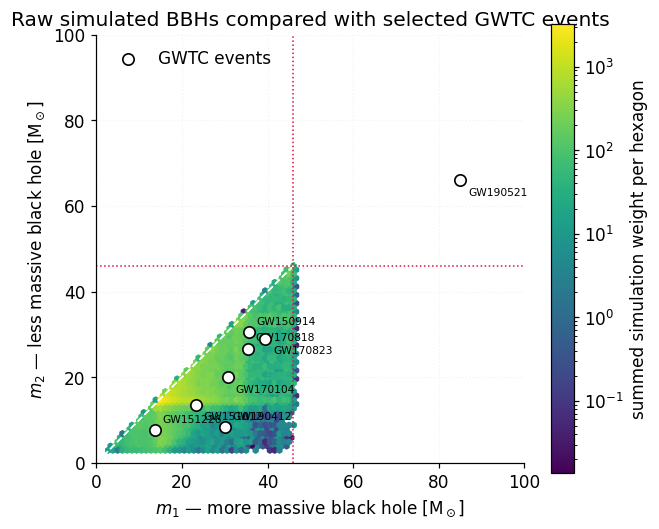

In [27]:
# Source-frame median component masses [Msun] from the GWOSC GWTC catalog.
# The first ten events are GWTC-1 BBHs; GW190412 and GW190521 add an
# unequal-mass system and the well-known high-mass outlier.
gwtc = pd.DataFrame({
    "event": ["GW150914", "GW151012", "GW151226", "GW170104",
              "GW170818", "GW170823", "GW190412", "GW190521"],
    "m1": [35.6, 23.2, 13.7, 30.8, 35.4, 39.5, 30.1, 85.0],
    "m2": [30.6, 13.6,  7.7, 20.0, 26.7, 29.0,  8.3, 66.0],
})

fig, ax = plt.subplots(figsize=(6, 5))
hb = ax.hexbin(bbh.m1, bbh.m2, C=bbh.w, reduce_C_function=np.sum,
               gridsize=90, extent=(0, 100, 0, 100), mincnt=1,
               norm=LogNorm(), cmap="viridis")
fig.colorbar(hb, ax=ax, label="summed simulation weight per hexagon")

ax.plot([0, 100], [0, 100], color="white", lw=1.2, ls="--")
ax.axvline(46, color="crimson", lw=1, ls=":")
ax.axhline(46, color="crimson", lw=1, ls=":")
ax.scatter(gwtc.m1, gwtc.m2, s=55, marker="o", facecolor="white",
           edgecolor="black", lw=1.1, label="GWTC events", zorder=4)

for i, row in gwtc.iterrows():
    offset = (5, 5) if i % 2 == 0 else (5, -10)
    ax.annotate(row.event, (row.m1, row.m2), xytext=offset,
                textcoords="offset points", fontsize=7, color="black")

ax.set(xlabel=r"$m_1$ — more massive black hole [M$_\odot$]",
       ylabel=r"$m_2$ — less massive black hole [M$_\odot$]",
       title="Raw simulated BBHs compared with selected GWTC events",
       xlim=(0, 100), ylim=(0, 100))
ax.set_aspect("equal")
ax.grid(alpha=0.15)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


Most of these observed systems overlap the broad region populated by the simulation, including the dense $m_1 \sim 10$–$40$ M$_\odot$ band. GW190521 is a conspicuous exception: its median component masses lie beyond the model's first-generation pair-instability boundary, so this isolated-binary population does not naturally explain it. The points use source-frame median masses from the [GWOSC event catalogue](https://gwosc.org/eventapi/html/GWTC/).

This visual comparison is **not a fair model test** for at least four reasons:

1. The simulation is a raw formation population, not integrated over cosmic star formation and metallicity history.
2. LIGO/Virgo preferentially detects massive systems over a much larger volume, so the observed sample is selection-biased.
3. Each measured mass has a broad, correlated posterior uncertainty; plotting only median points discards that information.
4. The model shown here includes one isolated-binary prescription, while the Universe may also contain dynamical or hierarchical mergers—especially relevant to GW190521.


### Exercise 6 — Two common envelopes (open-ended)

A small number of systems have `n_CE == 2`. Where do they sit in the $\log_{10}a$–$q$ plane, and
in the mass plane? Are they a third island, or do they hide inside island A? What kind of binary
would need *two* common envelopes?

Two-CE systems: 8,639 rows
Raw fraction of merging BBHs: 0.380%
Weighted fraction of merging BBHs: 0.309%
Weighted median q: 0.35
Weighted median separation: 10.12 Rsun
Weighted median masses: m1=18.3, m2=6.2 Msun


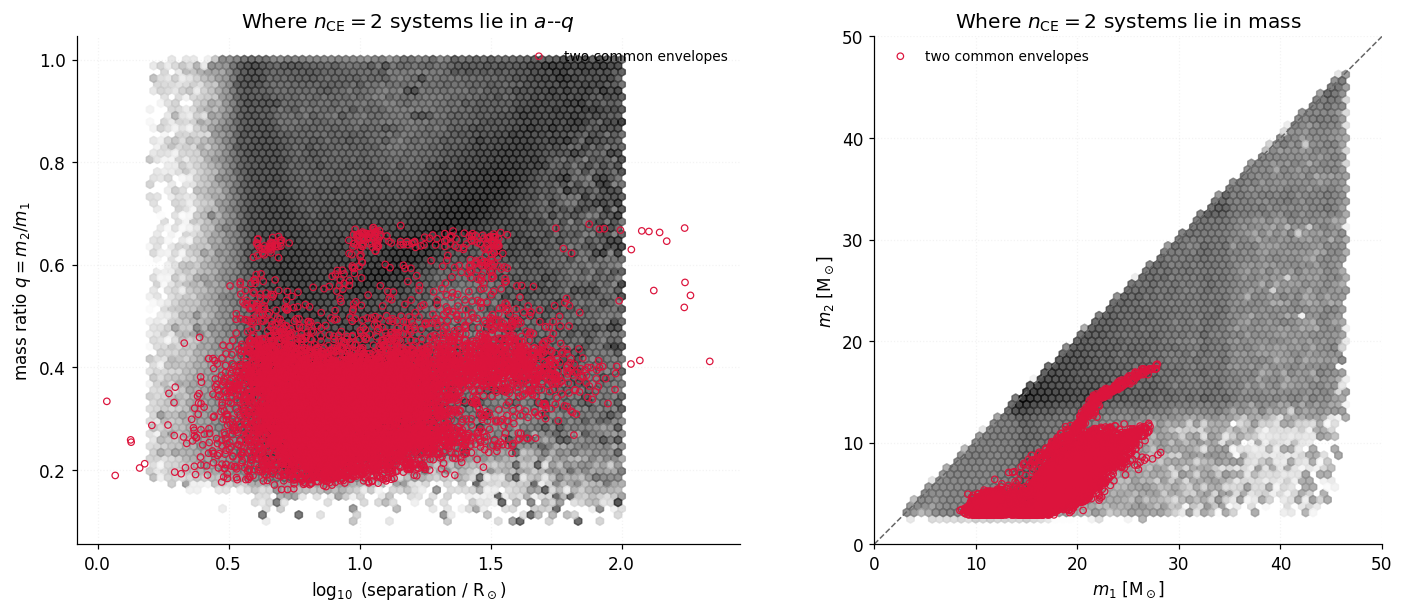

In [28]:
two_ce = bbh.n_CE == 2
one_ce = bbh.n_CE == 1
d2 = bbh[two_ce]

print(f"Two-CE systems: {two_ce.sum():,} rows")
print(f"Raw fraction of merging BBHs: {100 * two_ce.mean():.3f}%")
print(f"Weighted fraction of merging BBHs: {100 * d2.w.sum() / bbh.w.sum():.3f}%")
print(f"Weighted median q: {weighted_median(d2.q, d2.w):.2f}")
print(f"Weighted median separation: {weighted_median(d2.a_Rsun, d2.w):.2f} Rsun")
print(f"Weighted median masses: m1={weighted_median(d2.m1, d2.w):.1f}, "
      f"m2={weighted_median(d2.m2, d2.w):.1f} Msun")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.7))

# Panel 1: separation--mass-ratio plane
axes[0].hexbin(bbh.log_a, bbh.q, C=bbh.w, reduce_C_function=np.sum,
               gridsize=65, extent=(0.2, 2.0, 0.1, 1.0), mincnt=1,
               norm=LogNorm(), cmap="Greys", alpha=0.75)
axes[0].scatter(d2.log_a, d2.q, s=18, facecolor="none", edgecolor="crimson",
                lw=0.8, label="two common envelopes", zorder=3)
axes[0].set(xlabel=r"$\log_{10}$ (separation / R$_\odot$)",
            ylabel=r"mass ratio $q=m_2/m_1$",
            title=r"Where $n_{\rm CE}=2$ systems lie in $a$--$q$")
axes[0].legend(fontsize=9)

# Panel 2: component-mass plane
axes[1].hexbin(bbh.m1, bbh.m2, C=bbh.w, reduce_C_function=np.sum,
               gridsize=70, extent=(0, 50, 0, 50), mincnt=1,
               norm=LogNorm(), cmap="Greys", alpha=0.75)
axes[1].scatter(d2.m1, d2.m2, s=18, facecolor="none", edgecolor="crimson",
                lw=0.8, label="two common envelopes", zorder=3)
axes[1].plot([0, 50], [0, 50], color="0.4", ls="--", lw=1)
axes[1].set(xlabel=r"$m_1$ [M$_\odot$]", ylabel=r"$m_2$ [M$_\odot$]",
            title=r"Where $n_{\rm CE}=2$ systems lie in mass",
            xlim=(0, 50), ylim=(0, 50))
axes[1].set_aspect("equal")
axes[1].legend(fontsize=9)

for ax in axes:
    ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()


The red points overlap the compact, broad-$q$ common-envelope island rather than forming a separate third island; in the mass plane they likewise occupy part of the existing BBH population instead of defining a new branch. Their rarity is clearer from the weighted fraction than from the raw number of plotted rows.

A binary can experience two common envelopes when the stars evolve and become unstable mass donors at different times. The initially more evolved star can engulf its companion and leave a stripped core; later, after the companion evolves and expands, it can initiate a second unstable episode around that core or its compact remnant. Surviving both episodes removes large amounts of orbital energy and produces the tight systems seen inside the common-envelope island.


<a id="glossary"></a>
# Glossary

| Term | Meaning |
|---|---|
| **BBH** | Binary black hole: two black holes in orbit. |
| **BHNS / BNS** | Black hole–neutron star / binary neutron star. |
| **Chirp mass** $\mathcal{M}_c$ | $(m_1m_2)^{3/5}/(m_1+m_2)^{1/5}$; the best-measured mass combination in gravitational-wave data. |
| **Coalescence time** | Time from double-compact-object formation to merger. |
| **Common envelope (CE)** | Both stellar cores orbiting inside one shared gas envelope; drag shrinks the orbit dramatically. Highly uncertain physics. |
| **COMPAS** | *Compact Object Mergers: Population Astrophysics and Statistics* — the rapid population synthesis code that produced this data. |
| **Cosmic integration** | Folding population synthesis output together with the metallicity-dependent cosmic star formation history to predict observable merger rates. **Not done in this notebook.** |
| **DCO** | Double compact object. |
| **Delay time** | Birth of the stars → merger of the compact objects. |
| **HDF5** | Hierarchical binary file format for large scientific arrays; read with `h5py`. |
| **hexbin** | A 2D histogram drawn on a hexagonal grid; the right tool for millions of points. |
| **Hubble time** | ~13.7 Gyr; roughly the age of the Universe. Our cut for "does it merge". |
| **Importance sampling / STROOPWAFEL** | Deliberately oversampling the interesting region of parameter space, then correcting with weights. |
| **Mass ratio** $q$ | $m_2/m_1 \le 1$. |
| **Mass ratio reversal** | When the star born less massive ends up as the *more* massive compact object, because of mass transfer. |
| **Metallicity** $Z$ | Mass fraction of elements heavier than helium. Solar ≈ 0.014. |
| **PISN** | [Pair-instability supernova](https://en.wikipedia.org/wiki/Pair-instability_supernova): a very massive helium core is completely disrupted, leaving **no remnant**. Creates the mass gap. |
| **PPISN** | *Pulsational* pair-instability supernova: violent pulses eject mass but a black hole still forms, capped near ~45 M$_\odot$. Creates the pile-up below the gap. |
| **Peters' formula** | The gravitational-wave merger timescale, $t \propto a^4 / [m_1 m_2 (m_1+m_2)]$. |
| **RLOF** | Roche-lobe overflow: mass transfer. **Stable** RLOF is the alternative to a common envelope. |
| **SEED** | Unique per-binary ID; how you join different groups of the file. |
| **SMT channel** | Stable-mass-transfer channel: forms binary black holes without any common envelope. |
| **`mixture_weight`** | The statistical weight undoing the adaptive sampling bias. **Always use it.** |

# ✅ Summary — what you did

1. Opened a real, published, 5.6 GB **HDF5** population synthesis dataset and worked out what its
   groups, rows and columns mean.
2. Learned that simulated populations are usually **sampled unfairly on purpose**, and that
   `mixture_weight` is not optional — you saw it change an answer by a large factor.
3. Selected **merging binary black holes** using stellar types and the Hubble-time flag, and
   adopted the observational $m_1 \ge m_2$ convention.
4. Plotted the **black hole mass distribution** and explained every feature: the lower edge, the
   peak, the prescription fingerprints, and the **pair-instability mass gap** with its pile-up
   below and its rare "above the gap" black holes.
5. Plotted **2D distributions** and found that the population separates into **two islands** —
   and showed, with a single column of the data file, that those islands are the
   **common-envelope** and **stable-mass-transfer** formation channels, reproducing the central
   result of van Son et al. (2022).
6. Confirmed that **metallicity sets the maximum black hole mass**.

# ➡️ Next steps

- **Notebook 3: cosmic integration.** Everything here answered *"what did the code make?"*. The
  next notebook answers *"how many of these merge per year, per cubic gigaparsec, at each
  redshift — and what will LIGO actually see?"*. It uses the `Rates_...` group we deliberately
  skipped, plus the star formation history from
  [van Son et al. (2023)](https://arxiv.org/abs/2209.03385).

### Questions?

If the islands in Part 5 did not click, you are in good company — that plot compresses a lot of
binary physics into two axes. Bring it, and your Exercise 1 plot, to the next onboarding session.

---
*GROWL onboarding notebook 2 · data: van Son et al., [Zenodo 10.5281/zenodo.7612755](https://doi.org/10.5281/zenodo.7612755),
simulated with [COMPAS](https://compas.science/). Please cite the authors if you reuse it.*